# Compute scaling and capability transitions in Dense Addition Transformer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shoaibphysics/addition-transformers-jax/blob/main/notebooks/02_dense_addition_scaling_and_transitions.ipynb)



This notebook studies how model size and training duration should be balanced
under a fixed compute budget for three-digit addition. Following the
Chinchilla framework, we evaluate 110 dense decoder-only Transformer runs
across nine IsoFLOP budgets. Each endpoint is trained separately from initialization with a learning-rate
schedule matched to its horizon.

The resulting IsoFLOP profiles do not consistently exhibit the smooth,
well-resolved minima required by the standard quadratic analysis. A direct
parametric loss-surface fit is also strongly influenced by whether the known
full-sequence loss floor is estimated or fixed.

The experiment nevertheless reveals a clear scaling pattern in task
acquisition: larger models require fewer processed token positions to reach a
given exact-answer accuracy. We therefore retain the Chinchilla-style fits as
diagnostic estimates and treat the scaling of the exact-answer capability
boundary as the main empirical result.

> **Seed limitation.** All experiments use one fixed model-initialization and data-order seed configuration due to limited compute; multi-seed averaging is left for future work.

> **AI-use declaration.** Generative AI assisted with prose editing and portions of the analysis and plotting code. I designed and ran the experiments, verified the implementation and results, and take responsibility for the scientific interpretation.

## Scaling framework

### Compute-optimal allocation

Let

- $N$ be the number of trainable model parameters;
- $D$ be the number of token positions processed during training; and
- $C$ be the approximate training compute.

For a dense Transformer, we use the standard approximation

$$
C \approx 6ND.
$$

With batch size $B$, context length $T$, and $S$ optimizer steps,

$$
D=SBT,
$$

and therefore

$$
C\approx6NSBT.
$$

Here, $D$ measures total training exposure. It is not necessarily the number
of unique token positions because examples may be revisited across effective
epochs.

For a fixed compute budget, the compute-optimal allocation is defined by

$$
\left(
N_{\mathrm{opt}}(C),
D_{\mathrm{opt}}(C)
\right)
=
\operatorname*{arg\,min}_{N,D:\,6ND=C}
L(N,D),
$$

where $L(N,D)$ is the validation loss obtained after training a model with
$N$ parameters on $D$ processed token positions.

If a smooth compute-optimal frontier exists, it can be summarized by

$$
N_{\mathrm{opt}}(C)=K_NC^a,
\qquad
D_{\mathrm{opt}}(C)=K_DC^b,
$$

where $K_N$ and $K_D$ are constants. Since $C\propto ND$, the exponents must
satisfy

$$
a+b\approx1.
$$

The purpose of this notebook is to test whether the addition task supports
such a smooth frontier, rather than assuming that it does.

### Chinchilla-style estimators

We test the scaling hypothesis using two methods from
[Hoffmann et al. (2022)](https://arxiv.org/abs/2203.15556).

In **Approach 2**, several model sizes are trained at approximately the same
compute budget. Since

$$
D=\frac{C}{6N},
$$

smaller models receive more training tokens, while larger models receive
fewer. Plotting the final validation loss against model size produces an
IsoFLOP profile. If the profile contains a smooth interior minimum, its
location estimates the compute-optimal model size for that budget.

In **Approach 3**, all measured endpoints are fitted directly to the
parametric surface

$$
L(N,D)
=
E
+
\frac{A}{N^\alpha}
+
\frac{B}{D^\beta}.
$$

The three terms represent an irreducible loss floor, limited model capacity,
and limited training exposure. Under the constraint $C\approx6ND$, this
surface implies

$$
a=\frac{\beta}{\alpha+\beta},
\qquad
b=\frac{\alpha}{\alpha+\beta}.
$$

Both methods assume that loss changes smoothly enough with model size and
training exposure. One aim of the experiment is to check whether that
assumption remains appropriate for a small algorithmic task.

### Evaluation protocol and metrics

Each endpoint is evaluated on the complete 50,000-example validation split.
For a stored token sequence

$$
z=(z_0,z_1,\ldots,z_L),
$$

we construct the shifted input and target sequences

$$
x=(z_0,z_1,\ldots,z_{L-1}),
\qquad
y=(z_1,z_2,\ldots,z_L).
$$

The model receives the complete input sequence $x$ in one forward pass and
produces a next-token prediction at every position. Causal attention ensures
that the prediction at position $t$ can depend only on the prefix
$x_0,\ldots,x_t$, and its corresponding target is

$$
y_t=z_{t+1}.
$$

During evaluation, the model is always given the correct preceding tokens.
This is known as **teacher forcing**. It differs from free-running
autoregressive generation, where each generated token becomes part of the
context used to predict the next token.

One forward pass produces the logits used to calculate all three endpoint
metrics.

The **full-sequence validation NLL** averages next-token negative
log-likelihood over every genuine target position in the prompt and answer:

$$
L_{\mathrm{full}}
=
-
\frac{
\sum_{i,t}
m_{i,t}
\log p_\theta(y_{i,t}\mid x_{i,\leq t})
}{
\sum_{i,t}m_{i,t}
}.
$$

Here, $m_{i,t}$ is the ordinary loss mask, which excludes padding. This is the
training objective used throughout the experiment. Its theoretical minimum is
not zero because some prompt tokens remain unpredictable from their preceding
context.

The **answer-only validation NLL** uses an additional mask that selects only
the answer digits and terminating space:

$$
L_{\mathrm{answer}}
=
-
\frac{
\sum_{i,t}
a_{i,t}
\log p_\theta(y_{i,t}\mid x_{i,\leq t})
}{
\sum_{i,t}a_{i,t}
}.
$$

This is a continuous measure of the probability assigned to the correct answer
tokens. Its ideal floor is zero. It is reported as an evaluation diagnostic
and is not used as the training objective.

The **teacher-forced exact-answer accuracy** assigns an example a score of one
only when the argmax prediction is correct at every answer position, including
the terminating space:

$$
q
=
\frac{1}{n_{\mathrm{val}}}
\sum_i
\prod_{t:\,a_{i,t}=1}
\mathbf{1}
\left[
\operatorname*{arg\,max}_v
p_\theta(v\mid x_{i,\leq t})
=
y_{i,t}
\right].
$$

This is an all-or-nothing example-level metric, not token accuracy. A model can
therefore have gradually improving answer-only NLL while its exact-answer
accuracy changes much more sharply.

The exact-answer metric is calculated from a teacher-forced forward pass; it
does not execute the autoregressive generation loop.

## Experimental setup

### Runtime dependencies

This notebook can run in Google Colab or from a local Jupyter environment. In
Colab, the following cell installs fixed versions of Flax, Optax, and Orbax;
JAX is supplied by the selected Colab runtime. Local dependencies can instead
be installed from the locked project environment described in the README.

In [1]:
%pip -q install "flax==0.12.9" "optax==0.2.8" "orbax-checkpoint==0.12.4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.1/532.1 kB 17.8 MB/s eta 0:00:00


### Project source and outputs

A public Colab session clones the repository into the temporary runtime,
including the 110 saved endpoint records used below. Set
`USE_GOOGLE_DRIVE = True` only when running new experiments whose checkpoints
should persist across Colab sessions. When run locally, the notebook uses the
downloaded repository directly.

Each model-compute pair has a unique run identifier containing its compute
budget, model name, training horizon, and seed. Completed endpoints are reused
when the notebook is run again. Within the same runtime, an interrupted run can resume from its latest
checkpoint.

In [ ]:
# @title
import gc
import importlib.metadata
import subprocess
import sys
from dataclasses import replace
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np


PROJECT_NAME = "addition-transformers-jax"
EXPERIMENT_NAME = "02_dense_addition_scaling_and_transitions"
PROTOCOL_NAME = "dense-addition-isoflop-v1"

# PROJECT_ROOT = (Path("/content/drive/MyDrive") / "Colab Notebooks" / PROJECT_NAME)

REPOSITORY_URL = (
    "https://github.com/shoaibphysics/"
    "addition-transformers-jax.git"
)

# Leave False to reproduce the saved analysis directly.
# Set True before running new persistent Colab experiments.
USE_GOOGLE_DRIVE = False

try:
  from google.colab import drive
  IN_COLAB = True
except ImportError:
  IN_COLAB = False

if IN_COLAB:
  if USE_GOOGLE_DRIVE:
    drive.mount("/content/drive")

    PROJECT_ROOT = (
        Path("/content/drive/MyDrive")
        / "Colab Notebooks"
        / PROJECT_NAME
    )
  else:
    PROJECT_ROOT = Path("/content") / PROJECT_NAME

  if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT.parent.mkdir(parents=True, exist_ok=True)

    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            REPOSITORY_URL,
            str(PROJECT_ROOT),
        ],
        check=True,
    )

else:
  PROJECT_ROOT = next(
      (
          directory
          for directory in (Path.cwd(), *Path.cwd().parents)
          if (
              (directory / "pyproject.toml").is_file()
              and (
                  directory
                  / "src"
                  / "scaling_transformers_in_jax"
              ).is_dir()
          )
      ),
      None,
  )

  if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Run this notebook from inside the downloaded repository."
    )

SRC_DIR = PROJECT_ROOT / "src"

RUN_ROOT = (PROJECT_ROOT / "runs" / EXPERIMENT_NAME / PROTOCOL_NAME)

CHECKPOINT_ROOT = RUN_ROOT / "checkpoints"
RESULTS_DIR = RUN_ROOT / "results"
ANALYSIS_DIR = RUN_ROOT / "analysis"

for path in (CHECKPOINT_ROOT,RESULTS_DIR,ANALYSIS_DIR):
  path.mkdir(parents=True,exist_ok=True)

src_path = str(SRC_DIR)

if src_path not in sys.path:
  sys.path.insert(0,src_path)

print("JAX:", jax.__version__)
print("Flax:", importlib.metadata.version("flax"))
print("Optax:", importlib.metadata.version("optax"))
print("Orbax:", importlib.metadata.version("orbax-checkpoint"))
print("SciPy:", importlib.metadata.version("scipy"))
print("Backend:", jax.default_backend())
print("Devices:", jax.devices())
print("Run directory:", RUN_ROOT)

Mounted at /content/drive
JAX: 0.11.1
Flax: 0.12.9
Optax: 0.2.8
Orbax: 0.12.4
SciPy: 1.16.3
Backend: gpu
Devices: [CudaDevice(id=0)]
Run directory: /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/02_dense_addition_scaling_and_transitions/dense-addition-isoflop-v1


### Addition dataset

The dataset contains all one million ordered pairs of integers from 0 to 999.
A fixed random permutation divides them into 900,000 training examples, 50,000
validation examples, and 50,000 test examples.

Each pair is represented as a character-level sequence ending in a space token:

```text
123+456=579␠
```

Here, `␠` visually denotes the ordinary space character.

Each example is stored as a 13-character sequence, including its terminating
space and any required padding. Shifting the sequence produces input and target
sequences of length 12. The ordinary loss mask includes genuine next-token
targets through the first terminating space and excludes subsequent padding.

During evaluation, the answer mask begins at the input position containing
`=`. Because the targets are shifted by one position, this selects the first
answer digit, the remaining answer digits, and the terminating space.

The validation split is used for the endpoint measurements in this notebook.
The test split remains separate.

In [3]:
# @title
from scaling_transformers_in_jax.addition_data import (
    VOCAB,
    VOCAB_SIZE,
    SEQ_LEN,
    SPLIT_SEED,
    TRAIN_SIZE,
    VAL_SIZE,
    TEST_SIZE,
    create_addition_dataset)

dataset = create_addition_dataset()
train_pairs, train_x, train_y, train_mask = (dataset["train"])
val_pairs, val_x, val_y, val_mask = (dataset["val"])
test_pairs, test_x, test_y, test_mask = (dataset["test"])

assert train_x.shape == (TRAIN_SIZE, SEQ_LEN)
assert val_x.shape == (VAL_SIZE, SEQ_LEN)
assert test_x.shape == (TEST_SIZE, SEQ_LEN)

print("Vocabulary:", repr(VOCAB))
print("Vocabulary size:", VOCAB_SIZE)
print("Context length:", SEQ_LEN)
print("Split seed:", SPLIT_SEED)
print()
print("Training:", train_x.shape)
print("Validation:", val_x.shape)
print("Test:", test_x.shape)
print("Training device:", train_x.devices())

Vocabulary: '0123456789 +='
Vocabulary size: 13
Context length: 12
Split seed: 2026

Training: (900000, 12)
Validation: (50000, 12)
Test: (50000, 12)
Training device: {CudaDevice(id=0)}


### Sampling and training exposure

All runs use batch size $B=1024$ and context length $T=12$.

At the beginning of each effective epoch, the 900,000 training examples are
permuted using the fixed data-order seed. We retain only complete minibatches.
Therefore,

$$
\left\lfloor
\frac{900{,}000}{1024}
\right\rfloor
=878
$$

optimizer steps consume

$$
878\times1024
=
899{,}072
$$

examples. The remaining 928 examples are omitted from that epoch. Because the
data are reshuffled before the next epoch, the omitted examples generally
change.

No example is repeated within one effective epoch, although examples may
reappear after an epoch boundary. Runs using the same data-order seed follow
the same deterministic training stream. This also allows interrupted runs to
resume without changing their future minibatches.

Training exposure is measured in processed token positions,

$$
D=SBT=12{,}288S,
$$

where $S$ is the number of optimizer steps. Thus, $D$ measures total
training exposure rather than the amount of unique information in the finite
dataset.

We retain horizons satisfying

$$
128\leq S\leq5\times878=4390.
$$

The lower limit avoids extremely short optimization transients, while the
upper limit restricts every run to at most five effective epochs.

In [4]:
# @title
BATCH_SIZE = 1_024

MIN_STEPS = 128
MAX_EPOCHS = 5

STEPS_PER_EPOCH = (TRAIN_SIZE // BATCH_SIZE)
EXAMPLES_PER_EPOCH = (STEPS_PER_EPOCH * BATCH_SIZE)
EXAMPLES_DROPPED_PER_EPOCH = (TRAIN_SIZE - EXAMPLES_PER_EPOCH)
TOKEN_POSITIONS_PER_STEP = (BATCH_SIZE * SEQ_LEN)
MAX_STEPS = (MAX_EPOCHS * STEPS_PER_EPOCH)
MAX_TRAINING_TOKEN_POSITIONS = (MAX_STEPS * TOKEN_POSITIONS_PER_STEP)

assert BATCH_SIZE == 1_024
assert SEQ_LEN == 12
assert STEPS_PER_EPOCH == 878
assert MAX_STEPS == 4_390

print("Complete batches per epoch:", STEPS_PER_EPOCH)
print(f"Examples used per epoch: {EXAMPLES_PER_EPOCH:,}")
print(f"Examples omitted per epoch: {EXAMPLES_DROPPED_PER_EPOCH:,}")
print(f"Token positions per step: {TOKEN_POSITIONS_PER_STEP:,}")
print(f"Allowed step range: {MIN_STEPS:,}–{MAX_STEPS:,}")
print(f"Maximum processed token positions: {MAX_TRAINING_TOKEN_POSITIONS:,}")

Complete batches per epoch: 878
Examples used per epoch: 899,072
Examples omitted per epoch: 928
Token positions per step: 12,288
Allowed step range: 128–4,390
Maximum processed token positions: 53,944,320


#### Verifying the sampling order

Before constructing the experiment, we generate slightly more than one epoch
of indices twice. The checks below confirm that the same seed reproduces the
same order and that examples do not repeat within either epoch segment.

In [5]:
# @title
from scaling_transformers_in_jax.scaling_experiments import make_epochwise_training_order

verification_steps = STEPS_PER_EPOCH + 10

order_a = make_epochwise_training_order(
    num_examples=TRAIN_SIZE,
    batch_size=BATCH_SIZE,
    num_steps=verification_steps,
    seed=2_027)

order_b = make_epochwise_training_order(
    num_examples=TRAIN_SIZE,
    batch_size=BATCH_SIZE,
    num_steps=verification_steps,
    seed=2_027)

first_epoch = order_a[:EXAMPLES_PER_EPOCH]
second_epoch_prefix = order_a[EXAMPLES_PER_EPOCH:]

assert order_a.shape == (verification_steps * BATCH_SIZE,)
assert np.array_equal(order_a, order_b)
assert np.unique(first_epoch).size == first_epoch.size
assert np.unique(second_epoch_prefix).size == second_epoch_prefix.size

print("Order length:", f"{order_a.size:,}")
print("First epoch contains duplicates:", np.unique(first_epoch).size != first_epoch.size)
print("Same seed reproduces the order:", np.array_equal(order_a,order_b))

del (order_a, order_b, first_epoch, second_epoch_prefix)

Order length: 909,312
First epoch contains duplicates: False
Same seed reproduces the order: True


### Dense model family

The model ladder contains 21 decoder-only Transformers ranging from
approximately 57 thousand to 25 million trainable parameters. Every model uses
the same character vocabulary, context length, causal decoder, RoPE
implementation, RMSNorm and SwiGLU blocks, and next-token training objective.

Scale is changed by jointly varying `d_model`, depth, attention-head count, and
`d_ff`. The feed-forward width remains approximately proportional to
`d_model`, and each configuration has an even head dimension as required by
RoPE.

Guided by preliminary experiments, the ladder is intentionally dense at small
and intermediate scales, where performance changes most rapidly. Models above
10 million parameters provide coverage on the large-model side of the highest
compute budgets.

Because several architectural dimensions change together, the resulting laws
describe this particular model family rather than the isolated causal effect
of parameter count.

In [6]:
# @title
from scaling_transformers_in_jax.scaling_experiments import analytical_dense_parameter_count
from scaling_transformers_in_jax.transformer import ModelConfig


# name, d_model, layers, heads, d_ff
MODEL_SPECS = (
    ("dense-0p057m",  48, 2, 3,  128),
    ("dense-0p078m",  56, 2, 4,  152),
    ("dense-0p102m",  64, 2, 2,  176),
    ("dense-0p154m",  80, 2, 4,  208),
    ("dense-0p224m",  96, 2, 3,  256),
    ("dense-0p335m",  96, 3, 3,  256),
    ("dense-0p461m", 112, 3, 4,  304),
    ("dense-0p613m", 112, 4, 4,  304),
    ("dense-0p783m", 128, 4, 4,  336),
    ("dense-1p00m",  144, 4, 6,  384),
    ("dense-1p24m",  160, 4, 5,  432),
    ("dense-1p55m",  160, 5, 5,  432),
    ("dense-1p85m",  176, 5, 4,  464),
    ("dense-2p22m",  192, 5, 6,  512),
    ("dense-3p03m",  224, 5, 7,  600),
    ("dense-4p75m",  256, 6, 8,  688),
    ("dense-5p98m",  288, 6, 6,  768),
    ("dense-8p58m",  320, 7, 5,  848),
    ("dense-10p63m", 384, 6, 6, 1_024),
    ("dense-14p17m", 384, 8, 6, 1_024),
    ("dense-25p12m", 512, 8, 8, 1_360))


models = []

for (model_name, d_model, num_layers, num_heads, d_ff) in MODEL_SPECS:

  model_cfg = ModelConfig(
      vocab_size=VOCAB_SIZE,
      context_length=SEQ_LEN,
      d_model=d_model,
      num_layers=num_layers,
      num_heads=num_heads,
      d_ff=d_ff)

  assert model_cfg.d_model % model_cfg.num_heads == 0

  assert model_cfg.head_dim % 2 == 0

  parameter_count = analytical_dense_parameter_count(model_cfg)

  models.append((model_name, model_cfg, parameter_count))

MODELS = tuple(models)

del models

parameter_counts = np.asarray([parameter_count for _, _, parameter_count in MODELS])

assert np.all(np.diff(parameter_counts) > 0)
assert len(parameter_counts) == len(np.unique(parameter_counts))

print(f"{'model':<16}"
      f"{'d_model':>9}"
      f"{'layers':>9}"
      f"{'heads':>8}"
      f"{'d_ff':>8}"
      f"{'parameters':>14}")

for (model_name, model_cfg, parameter_count) in MODELS:
  print(f"{model_name:<16}"
        f"{model_cfg.d_model:>9}"
        f"{model_cfg.num_layers:>9}"
        f"{model_cfg.num_heads:>8}"
        f"{model_cfg.d_ff:>8}"
        f"{parameter_count:>14,}")

model             d_model   layers   heads    d_ff    parameters
dense-0p057m           48        2       3     128        56,784
dense-0p078m           56        2       4     152        77,896
dense-0p102m           64        2       2     176       102,336
dense-0p154m           80        2       4     208       153,520
dense-0p224m           96        2       3     256       224,160
dense-0p335m           96        3       3     256       334,944
dense-0p461m          112        3       4     304       460,656
dense-0p613m          112        4       4     304       613,200
dense-0p783m          128        4       4     336       782,720
dense-1p00m           144        4       6     384     1,000,368
dense-1p24m           160        4       5     432     1,244,640
dense-1p55m           160        5       5     432     1,554,720
dense-1p85m           176        5       4     464     1,850,992
dense-2p22m           192        5       6     512     2,218,944
dense-3p03m           224

### Horizon-matched optimization

Every model-compute endpoint is trained separately from initialization using
the same fixed seeds. A
short run is not represented by an intermediate checkpoint from a longer run,
because that checkpoint would have been trained under a learning-rate schedule
designed for a different endpoint.

For a run lasting $S$ optimizer steps, the learning rate warms up linearly
for approximately $5\%$ of the run and then follows cosine decay to its final
value at step $S$:

$$
S_{\mathrm{warmup}}
=
\max\left(
1,
\operatorname{round}(0.05S)
\right).
$$

All models use a peak learning rate of $3\times10^{-4}$, a final learning rate
of $3\times10^{-5}$, and the same AdamW, weight-decay, and gradient-clipping
settings.

Training and monitor-validation losses are recorded at approximately 20 points
per run. These measurements are used to inspect optimization, while the final
scaling analysis uses the complete 50,000-example validation split.

In [7]:
# @title
from scaling_transformers_in_jax.training import TrainConfig


BASE_TRAIN_CFG = TrainConfig(
    batch_size=BATCH_SIZE,
    num_eval_batches=1,
    peak_learning_rate=3e-4,
    end_learning_rate=3e-5,
    max_grad_norm=1.0,
    weight_decay=0.1,
    adam_epsilon=1e-8,
    adam_beta1=0.9,
    adam_beta2=0.95)


def make_train_config(num_steps):
  """Create an optimization schedule matched to one endpoint."""
  num_steps = int(num_steps)

  if not (MIN_STEPS <= num_steps <= MAX_STEPS):
    raise ValueError(f"num_steps must lie between {MIN_STEPS} and {MAX_STEPS}.")

  return replace(
      BASE_TRAIN_CFG,
      log_every=max(1,num_steps // 20),
      checkpoint_every=max(64,num_steps // 4),
      warmup_steps=max(1,round(0.05 * num_steps)),
      learning_rate_decay_step=(num_steps),
      num_steps=num_steps)

In [8]:
# @title
for num_steps in (MIN_STEPS, STEPS_PER_EPOCH, MAX_STEPS):

  train_cfg = make_train_config(num_steps)

  print(f"{num_steps:>5,} steps | "
        f"warmup={train_cfg.warmup_steps:>3,} | "
        f"decay end={train_cfg.learning_rate_decay_step:>5,} | "
        f"log every={train_cfg.log_every:>3,} | "
        f"effective epochs="
        f"{num_steps / STEPS_PER_EPOCH:.3f}")

  128 steps | warmup=  6 | decay end=  128 | log every=  6 | effective epochs=0.146
  878 steps | warmup= 44 | decay end=  878 | log every= 43 | effective epochs=1.000
4,390 steps | warmup=220 | decay end=4,390 | log every=219 | effective epochs=5.000


## IsoFLOP experiment

We evaluate nine logarithmically spaced target compute budgets between

$$
10^{13}
\quad\text{and}\quad
10^{14.5}.
$$

Throughout this notebook, compute refers to the analytical approximation

$$
C\approx 6ND,
$$

rather than measured device FLOPs. Preliminary experiments informed the range and density of the grid, but their measurements are not included because they used different sampling protocols.

For each target compute $C$ and parameter count $N$, the corresponding
training horizon is

$$
S_{\mathrm{target}}
=
\frac{C}{6NBT}.
$$

After rounding to an integer number of optimizer steps, the actual budgets are

$$
D_{\mathrm{actual}}=SBT,
\qquad
C_{\mathrm{actual}}=6ND_{\mathrm{actual}}.
$$

Only combinations satisfying

$$
128\leq S\leq 4390
$$

are retained. This excludes very large models from the lowest compute budgets
and very small models from the highest ones, leaving 110 scheduled endpoints.

All endpoints use the same initialization-seed value and the same fixed
data-order seed. This makes the sweep reproducible, but it remains a
single-seed experiment and does not measure variation across independent
training runs.

In [9]:
# @title
FLOP_FACTOR = 6

COMPUTE_BUDGETS = np.logspace(13.0,14.5,9)

EXPERIMENT_SEED = 0
MODEL_SEED = EXPERIMENT_SEED

TRAINING_SEED = (2_027 + EXPERIMENT_SEED)
TRAINING_SAMPLING = "epoch_shuffle"

runs = []

for (compute_index, target_training_compute) in enumerate(COMPUTE_BUDGETS, start=1):

  target_training_compute = float(target_training_compute)

  for (model_name, model_cfg, parameter_count) in MODELS:

    target_steps = (target_training_compute / (FLOP_FACTOR * parameter_count * BATCH_SIZE * SEQ_LEN ))
    num_steps = int(np.rint(target_steps))

    if not (MIN_STEPS <= num_steps <= MAX_STEPS):
      continue

    training_token_positions = (num_steps * BATCH_SIZE * SEQ_LEN)
    training_compute_approx = (FLOP_FACTOR * parameter_count * training_token_positions)
    relative_compute_error = ((training_compute_approx - target_training_compute) / target_training_compute)

    run_id = (f"{PROTOCOL_NAME}"
              f"__c-{compute_index:02d}"
              f"__{model_name}"
              f"__steps-{num_steps:05d}"
              f"__seed-{EXPERIMENT_SEED:02d}")

    runs.append({
        "compute_index": compute_index,
        "target_training_compute": (target_training_compute),
        "run_id": run_id,
        "model_name": model_name,
        "model_cfg": model_cfg,
        "parameter_count": (parameter_count),
        "num_steps": num_steps,
        "train_cfg": make_train_config(num_steps),
        "training_token_positions": (training_token_positions),
        "training_compute_approx": (training_compute_approx),
        "relative_compute_error": float(relative_compute_error),
        "seed": EXPERIMENT_SEED,
        "model_seed": MODEL_SEED,
        "training_seed": TRAINING_SEED})

RUNS = tuple(runs)

del runs

### Experiment-grid consistency checks

Rounding the number of optimizer steps causes a small difference between the
target and actual compute of each endpoint. Before training, we verify that all
run identifiers are unique, every horizon satisfies the predefined limits,
each compute budget contains several candidate models, all 110 intended runs
are present, and the compute-rounding error remains below $0.4\%$.

These checks establish that the experimental grid is internally consistent.
Whether its IsoFLOP profiles contain smooth, identifiable minima can only be
determined from the trained endpoints.

In [10]:
# @title
assert len(RUNS) == len({run["run_id"] for run in RUNS})
assert all(MIN_STEPS <= run["num_steps"] <= MAX_STEPS for run in RUNS)

expected_models_per_budget = (10,12,13,12,12,13,14,12,12)

print(f"{'budget':>6} | "
      f"{'target C':>11} | "
      f"{'model range':>19} | "
      f"{'runs':>4} | "
      f"{'step range':>14} | "
      f"{'max error':>10}")

print("-" * 78)

observed_models_per_budget = []

for (compute_index, target_training_compute) in enumerate(COMPUTE_BUDGETS, start=1):

  budget_runs = [run for run in RUNS if (run["compute_index"] == compute_index)]
  observed_models_per_budget.append(len(budget_runs))
  minimum_parameters = min(run["parameter_count"] for run in budget_runs)
  maximum_parameters = max(run["parameter_count"] for run in budget_runs)
  minimum_steps = min(run["num_steps"] for run in budget_runs)
  maximum_steps = max(run["num_steps"] for run in budget_runs)
  maximum_error = max(abs(run["relative_compute_error"]) for run in budget_runs)
  model_range = (f"{minimum_parameters / 1e6:.3f}–{maximum_parameters / 1e6:.3f}M")
  step_range = (f"{minimum_steps:,}–{maximum_steps:,}")

  print(f"{compute_index:>6} | "
        f"{target_training_compute:>11.3e} | "
        f"{model_range:>19} | "
        f"{len(budget_runs):>4} | "
        f"{step_range:>14} | "
        f"{maximum_error:>9.3%}")

assert tuple(observed_models_per_budget) == expected_models_per_budget
assert max(abs(run["relative_compute_error"]) for run in RUNS) < 0.004
assert len(RUNS) == 110

print()
print("Total runs:", len(RUNS))
print("Experiment seed:", EXPERIMENT_SEED)
print("Model seed:", MODEL_SEED)
print("Training seed:", TRAINING_SEED)
print("Training sampling:", TRAINING_SAMPLING)

budget |    target C |         model range | runs |     step range |  max error
------------------------------------------------------------------------------
     1 |   1.000e+13 |        0.057–1.000M |   10 |      136–2,389 |    0.307%
     2 |   1.540e+13 |        0.057–1.555M |   12 |      134–3,678 |    0.255%
     3 |   2.371e+13 |        0.078–2.219M |   13 |      145–4,129 |    0.162%
     4 |   3.652e+13 |        0.154–3.028M |   12 |      164–3,226 |    0.255%
     5 |   5.623e+13 |        0.224–4.753M |   12 |      160–3,403 |    0.291%
     6 |   8.660e+13 |        0.335–8.579M |   13 |      137–3,507 |    0.156%
     7 |   1.334e+14 |       0.461–14.172M |   14 |      128–3,926 |    0.296%
     8 |   2.054e+14 |       0.783–14.172M |   12 |      197–3,558 |    0.239%
     9 |   3.162e+14 |       1.000–25.122M |   12 |      171–4,288 |    0.159%

Total runs: 110
Experiment seed: 0
Model seed: 0
Training seed: 2027
Training sampling: epoch_shuffle


### Visualizing the training grid

The figure below shows the full $21\times9$ candidate rectangle together
with the subset that satisfies the optimizer-step limits.

Hollow squares are excluded combinations. Colored squares are the 110
scheduled runs, with color indicating the effective number of passes through
the training split,

$$
\text{effective epochs}
=
\frac{S}{878}.
$$

The diagonal band follows from the fixed-compute tradeoff: at the same compute
budget, a smaller model can take more optimizer steps, whereas a larger model
must take fewer.

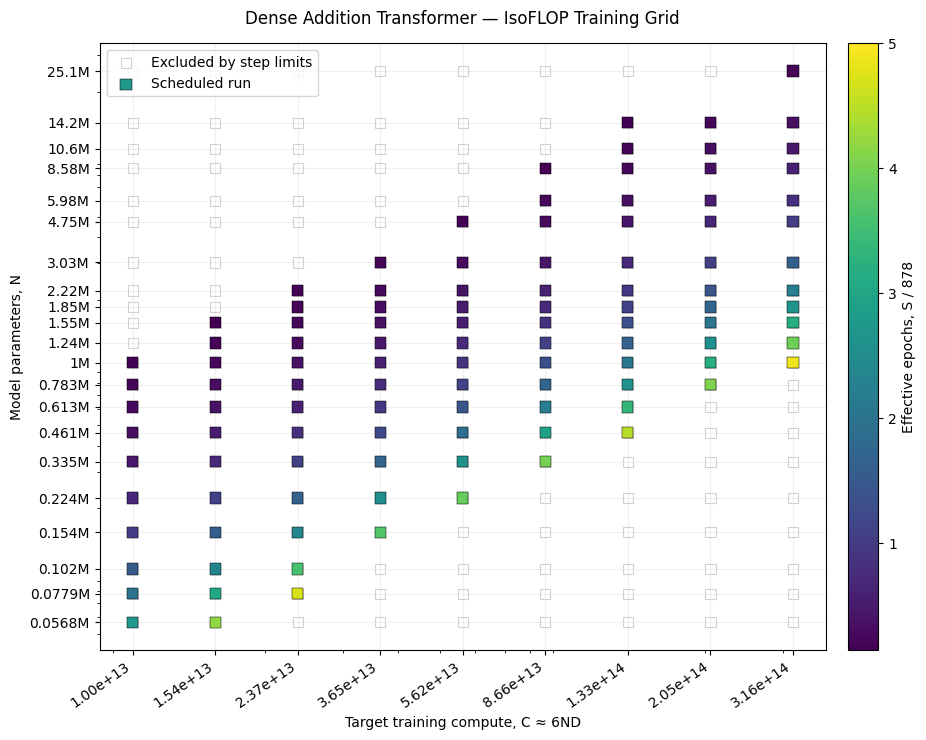

Saved grid to: /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/02_dense_addition_scaling_and_transitions/dense-addition-isoflop-v1/analysis/isoflop_training_grid.png


In [11]:
# @title
all_grid_compute = np.repeat(
    COMPUTE_BUDGETS,
    len(MODELS))

all_grid_parameters = np.tile(
    parameter_counts,
    len(COMPUTE_BUDGETS))

scheduled_compute = np.asarray([
    run["target_training_compute"]
    for run in RUNS
])

scheduled_parameters = np.asarray([
    run["parameter_count"]
    for run in RUNS
])

scheduled_epochs = np.asarray([
    run["num_steps"]
    / STEPS_PER_EPOCH
    for run in RUNS
])


grid_plot_path = (
    ANALYSIS_DIR
    / "isoflop_training_grid.png")

figure, axis = plt.subplots(
    figsize=(10, 7.5))

# Show the full model-by-compute rectangle.
axis.scatter(
    all_grid_compute,
    all_grid_parameters,
    marker="s",
    s=55,
    facecolors="none",
    edgecolors="lightgray",
    linewidths=0.8,
    label="Excluded by step limits",
    zorder=1)

# Overlay the combinations that will be trained.
scheduled_points = axis.scatter(
    scheduled_compute,
    scheduled_parameters,
    c=scheduled_epochs,
    cmap="viridis",
    vmin=MIN_STEPS / STEPS_PER_EPOCH,
    vmax=MAX_EPOCHS,
    marker="s",
    s=65,
    edgecolors="black",
    linewidths=0.35,
    label="Scheduled run",
    zorder=2)

axis.set_xscale("log")
axis.set_yscale("log")

axis.set_xticks(
    COMPUTE_BUDGETS)

axis.set_xticklabels(
    [
        f"{compute:.2e}"
        for compute in COMPUTE_BUDGETS
    ],
    rotation=35,
    ha="right")

axis.set_yticks(
    parameter_counts)

axis.set_yticklabels([
    f"{count / 1e6:.3g}M"
    for count in parameter_counts
])

axis.set_xlabel(
    "Target training compute, C ≈ 6ND")

axis.set_ylabel(
    "Model parameters, N")

axis.set_title(
    "Dense Addition Transformer — IsoFLOP Training Grid",
    pad=14)

axis.grid(
    alpha=0.18,
    which="major")

axis.legend(
    loc="upper left")

colorbar = figure.colorbar(
    scheduled_points,
    ax=axis,
    pad=0.025)

colorbar.set_label(
    "Effective epochs, S / 878")

figure.tight_layout()

figure.savefig(
    grid_plot_path,
    dpi=150,
    bbox_inches="tight")

plt.show()

print(
    "Saved grid to:",
    grid_plot_path)

## Running the experiment

### Smoke test

Before launching the full sweep, we execute one inexpensive endpoint and check
its saved result. We choose the run requiring the fewest optimizer steps at
the smallest compute budget.

This endpoint already belongs to the 110-run manifest, so the smoke test does
not create a duplicate experiment. The full sweep will detect and reuse its
saved result. If execution is interrupted, the partial run remains
checkpointed and resumes when the cell is run again.

In [12]:
# @title
from scaling_transformers_in_jax.scaling_experiments import (run_dense_scaling_experiment)


smallest_compute_runs = [run for run in RUNS if run["compute_index"] == 1]
SMOKE_RUN = min(smallest_compute_runs, key=lambda run: run["num_steps"])
del smallest_compute_runs

print("Smoke-test run:")
print("  ID:", SMOKE_RUN["run_id"])
print("  Model:", SMOKE_RUN["model_name"])
print(f"  Parameters: {SMOKE_RUN['parameter_count']:,}")
print(f"  Target compute: {SMOKE_RUN['target_training_compute']:.3e}")
print(f"  Steps: {SMOKE_RUN['num_steps']:,}")
print(f"  Effective epochs: {SMOKE_RUN['num_steps'] / STEPS_PER_EPOCH:.3f}")

Smoke-test run:
  ID: dense-addition-isoflop-v1__c-01__dense-1p00m__steps-00136__seed-00
  Model: dense-1p00m
  Parameters: 1,000,368
  Target compute: 1.000e+13
  Steps: 136
  Effective epochs: 0.155


In [13]:
# @title
RUN_SMOKE_TEST = False
smoke_result = None

if RUN_SMOKE_TEST:
  try:
    smoke_result = (
        run_dense_scaling_experiment(
            protocol=PROTOCOL_NAME,
            run_id=SMOKE_RUN["run_id"],
            model_cfg=SMOKE_RUN["model_cfg"],
            train_cfg=SMOKE_RUN["train_cfg"],
            model_seed=SMOKE_RUN["model_seed"],
            training_seed=SMOKE_RUN["training_seed"],
            dataset=dataset,
            checkpoint_root=(CHECKPOINT_ROOT),
            results_dir=RESULTS_DIR,
            validation_monitor_size=1_024,
            endpoint_batch_size=1_000,
            max_to_keep=1,
            training_sampling=(TRAINING_SAMPLING),
            target_training_compute=(SMOKE_RUN["target_training_compute"])))
  finally:
    jax.clear_caches()
    gc.collect()
else:
  print("Smoke-test training is disabled.")

Smoke-test training is disabled.


#### Smoke-test validation

A successful endpoint must reproduce the intended run identity, complete the requested number of optimizer steps, evaluate all 50,000 validation examples, and remain within the permitted compute-rounding error.

The numerical losses are not expected to be good for this deliberately undertrained model. This check concerns execution and metadata correctness rather than model quality.

In [14]:
# @title
if smoke_result is None:
  print("The smoke test has not completed. Re-run the training cell to resume it.")

else:
  validation = smoke_result["validation"]
  assert (smoke_result["run_id"] == SMOKE_RUN["run_id"])
  assert (smoke_result["parameter_count"] == SMOKE_RUN["parameter_count"])
  assert (smoke_result["optimizer_steps"] == SMOKE_RUN["num_steps"])
  assert (smoke_result["data"]["training_sampling"] == TRAINING_SAMPLING)
  assert np.isclose(smoke_result["target_training_compute"], SMOKE_RUN["target_training_compute"])
  assert (abs(smoke_result["relative_compute_error"]) < 0.004)
  assert (validation["example_count"] == VAL_SIZE)
  assert (smoke_result["unique_training_examples"] == smoke_result["training_examples"])
  assert (smoke_result["training_history"][-1]["step"] == SMOKE_RUN["num_steps"])

  print("Smoke test passed.")
  print()
  print("Completed steps:", f"{smoke_result['optimizer_steps']:,}")
  print("Training examples:", f"{smoke_result['training_examples']:,}")
  print("Unique training examples:", f"{smoke_result['unique_training_examples']:,}")
  print("Effective epochs:", f"{smoke_result['effective_epochs']:.3f}")
  print("Compute error:", f"{smoke_result['relative_compute_error']:.3%}")
  print("Full validation NLL:", f"{validation['full_loss']:.6f}")
  print("Answer-only validation NLL:", f"{validation['answer_loss']:.6f}")
  print("Teacher-forced exact-answer accuracy:", f"{validation['exact_answer_accuracy']:.6f}")
  print("Validation examples:", f"{validation['example_count']:,}")

The smoke test has not completed. Re-run the training cell to resume it.


### Full 110-run sweep

The following cell is the entry point for the complete experiment. Set
`RUN_TRAINING = True` to launch or resume the sweep. Once all endpoint files
exist, leave it set to `False` when rerunning only the analysis.

For every scheduled endpoint, the runner initializes or restores the model,
reconstructs its deterministic training stream, applies the horizon-matched
schedule, saves periodic checkpoints, evaluates the complete validation split,
and writes one endpoint-result file.

Completed endpoints are validated and reused rather than retrained. If the
loop is interrupted, the current run remains resumable and the sweep stops
before moving to the next endpoint.

In [15]:
# Keep False when re-running the saved analysis.
RUN_TRAINING = False

RUNS_TO_EXECUTE = RUNS

if RUN_TRAINING:
  for index, run in enumerate(RUNS_TO_EXECUTE,start=1):

    print()
    print(f"Run {index}/{len(RUNS_TO_EXECUTE)}:", run["run_id"])

    run_result = None

    try:
      run_result = (
          run_dense_scaling_experiment(
              protocol=PROTOCOL_NAME,
              run_id=run["run_id"],
              model_cfg=run["model_cfg"],
              train_cfg=run["train_cfg"],
              model_seed=run["model_seed"],
              training_seed=run["training_seed"],
              dataset=dataset,
              checkpoint_root=(CHECKPOINT_ROOT),
              results_dir=RESULTS_DIR,
              validation_monitor_size=1_024,
              endpoint_batch_size=1_000,
              max_to_keep=1,
              training_sampling=(TRAINING_SAMPLING),
              target_training_compute=(run["target_training_compute"])))
    finally:
      jax.clear_caches()
      gc.collect()

    # A manual interruption saves the current
    # run and then stops the complete grid.
    if run_result is None:
      print()
      print("The grid stopped before the current run reached its endpoint.")
      print("Re-run this cell to restore that run and continue the grid.")
      break

else:
  print("Training is disabled. Set RUN_TRAINING = True to run the grid.")

Training is disabled. Set RUN_TRAINING = True to run the grid.


## Results

### Loading the completed runs

Each run saves its endpoint measurements in a separate result file. We load
only the files corresponding to the 110 planned runs and check that each one was
created using the expected experimental protocol.

We also check the sampling method, validation-set size, and compute-rounding
error. The analysis continues only after all 110 results are available. Any
unrelated JSON files in the results directory are ignored.

In [16]:
# @title
from scaling_transformers_in_jax.scaling_experiments import load_scaling_results


EXPECTED_RUN_IDS = tuple(run["run_id"] for run in RUNS)

records, missing_run_ids = (
    load_scaling_results(
        results_dir=RESULTS_DIR,
        expected_run_ids=(EXPECTED_RUN_IDS),
        expected_protocol=(PROTOCOL_NAME)))

RECORDS = tuple(records)
GRID_COMPLETE = (len(missing_run_ids) == 0)

print("Completed endpoints:", f"{len(RECORDS)}/{len(RUNS)}")
print("Missing endpoints:", len(missing_run_ids))

if missing_run_ids:
  print()
  print("First missing run IDs:")

  for run_id in missing_run_ids[:10]:
    print(" ", run_id)

else:
  assert len(RECORDS) == 110
  assert all(record["data"]["training_sampling"] == TRAINING_SAMPLING for record in RECORDS)
  assert all(record["validation"]["example_count"] == VAL_SIZE for record in RECORDS)
  assert all(abs(record["relative_compute_error"])< 0.004 for record in RECORDS)

  full_losses = np.asarray([record["validation"]["full_loss"] for record in RECORDS])
  answer_losses = np.asarray([record["validation"]["answer_loss"] for record in RECORDS])

  accuracies = np.asarray([record["validation"]["exact_answer_accuracy"] for record in RECORDS])

  print()
  print("The complete grid is ready.")
  print("Full-NLL range:", f"{full_losses.min():.6f}–{full_losses.max():.6f}")
  print("Answer-NLL range:", f"{answer_losses.min():.6g}–{answer_losses.max():.6g}")
  print("Accuracy range:", f"{accuracies.min():.6f}–{accuracies.max():.6f}")

Completed endpoints: 110/110
Missing endpoints: 0

The complete grid is ready.
Full-NLL range: 1.034237–1.660659
Answer-NLL range: 0.000639024–1.49173
Accuracy range: 0.003060–0.999520


### Approach 2: observed IsoFLOP profiles

For each target compute budget, we group the separately trained endpoints and
order them by parameter count. The lowest measured full-sequence validation
NLL gives the best *observed* allocation on that profile.

In Chinchilla Approach 2, a quadratic is fitted in log parameter count around
a smooth interior minimum. Before applying that interpolation, we check whether
the measured minimum lies inside the available model range and whether its two
immediate neighbours have higher loss.

The table labels such a point `bracketed`. This is necessary for a local
minimum, but it does not by itself show that the surrounding profile is smooth
or approximately parabolic.

In [17]:
# @title
ISOFLOP_PROFILES = tuple(
    tuple(sorted(
        (
            record
            for record in RECORDS
            if np.isclose(
                record["target_training_compute"],
                target_compute,
                rtol=1e-12,
                atol=0.0)
        ),
        key=lambda record:
            record["parameter_count"]))
    for target_compute in COMPUTE_BUDGETS
)

assert tuple(
    len(profile)
    for profile in ISOFLOP_PROFILES
) == expected_models_per_budget


PROFILE_SUMMARY = []

print(
    f"{'budget':>6} | "
    f"{'target C':>11} | "
    f"{'points':>6} | "
    f"{'best N':>9} | "
    f"{'best D':>9} | "
    f"{'full NLL':>8} | "
    f"{'answer NLL':>10} | "
    f"{'accuracy':>8} | "
    f"minimum")

print("-" * 105)

for compute_index, (
    target_compute,
    profile
) in enumerate(
    zip(
        COMPUTE_BUDGETS,
        ISOFLOP_PROFILES),
    start=1):

  losses = np.asarray([
      record["validation"]["full_loss"]
      for record in profile
  ])

  best_index = int(
      np.argmin(losses))

  best_record = profile[
      best_index]

  interior = (
      0
      < best_index
      < len(profile) - 1)

  locally_bracketed = (
      interior
      and losses[best_index - 1]
      > losses[best_index]
      and losses[best_index + 1]
      > losses[best_index])

  if locally_bracketed:
    minimum_status = "bracketed"
  elif interior:
    minimum_status = "not bracketed"
  else:
    minimum_status = "boundary"

  PROFILE_SUMMARY.append({
      "compute_index": compute_index,
      "target_compute": float(
          target_compute),
      "profile": profile,
      "best_index": best_index,
      "best_record": best_record,
      "interior": interior,
      "locally_bracketed": (
          locally_bracketed),
  })

  validation = best_record[
      "validation"]

  print(
      f"{compute_index:>6} | "
      f"{target_compute:>11.3e} | "
      f"{len(profile):>6} | "
      f"{best_record['parameter_count'] / 1e6:>8.3f}M | "
      f"{best_record['training_token_positions'] / 1e6:>8.3f}M | "
      f"{validation['full_loss']:>8.5f} | "
      f"{validation['answer_loss']:>10.6f} | "
      f"{validation['exact_answer_accuracy']:>8.5f} | "
      f"{minimum_status}")

budget |    target C | points |    best N |    best D | full NLL | answer NLL | accuracy | minimum
---------------------------------------------------------------------------------------------------------
     1 |   1.000e+13 |     10 |    0.078M |   21.393M |  1.48724 |   1.130880 |  0.01048 | bracketed
     2 |   1.540e+13 |     12 |    0.154M |   16.724M |  1.38124 |   0.860255 |  0.11570 | bracketed
     3 |   2.371e+13 |     13 |    0.154M |   25.743M |  1.23915 |   0.508313 |  0.38196 | bracketed
     4 |   3.652e+13 |     12 |    0.154M |   39.641M |  1.12169 |   0.215257 |  0.71166 | boundary
     5 |   5.623e+13 |     12 |    0.613M |   15.286M |  1.16093 |   0.309971 |  0.61590 | bracketed
     6 |   8.660e+13 |     13 |    1.000M |   14.426M |  1.05583 |   0.051097 |  0.94852 | bracketed
     7 |   1.334e+14 |     14 |    1.000M |   22.217M |  1.03853 |   0.009890 |  0.98936 | bracketed
     8 |   2.054e+14 |     12 |    1.000M |   34.210M |  1.03524 |   0.002562 |  0.99708 

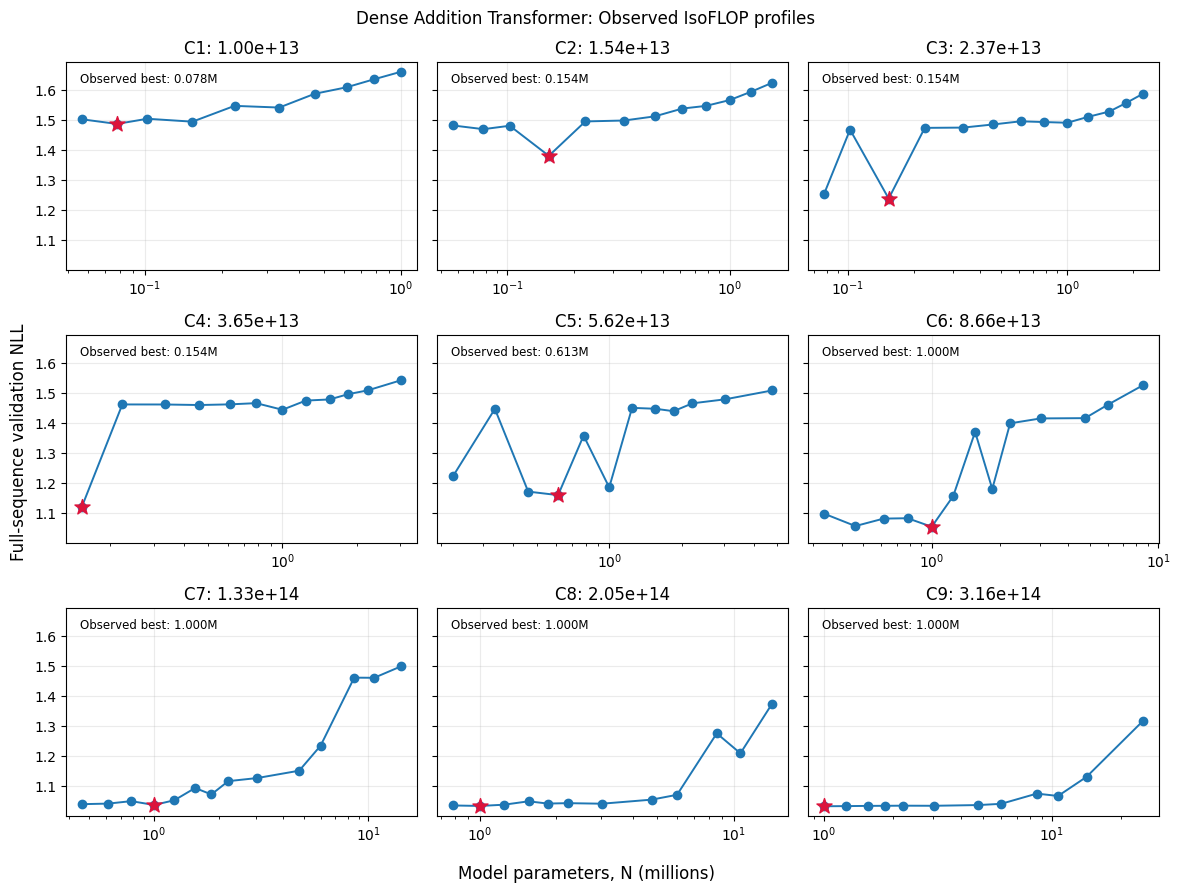

Saved profiles to: /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/02_dense_addition_scaling_and_transitions/dense-addition-isoflop-v1/analysis/observed_isoflop_profiles.png


In [18]:
# @title
# AI-use declaration: This code block is mostly written by AI

profile_plot_path = (
    ANALYSIS_DIR
    / "observed_isoflop_profiles.png")

figure, axes = plt.subplots(
    3,
    3,
    figsize=(12, 9),
    sharey=True)

for summary, axis in zip(
    PROFILE_SUMMARY,
    axes.flat):

  profile = summary["profile"]

  parameters = np.asarray([
      record["parameter_count"]
      for record in profile
  ])

  losses = np.asarray([
      record["validation"]["full_loss"]
      for record in profile
  ])

  best_index = summary[
      "best_index"]

  axis.plot(
      parameters / 1e6,
      losses,
      marker="o",
      linewidth=1.4)

  axis.scatter(
      parameters[best_index] / 1e6,
      losses[best_index],
      marker="*",
      s=130,
      color="crimson",
      zorder=3)

  axis.set_xscale("log")

  axis.set_title(
      f"C{summary['compute_index']}: "
      f"{summary['target_compute']:.2e}")

  axis.grid(
      alpha=0.25)

  axis.text(
      0.04,
      0.95,
      f"Observed best: "
      f"{parameters[best_index] / 1e6:.3f}M",
      transform=axis.transAxes,
      ha="left",
      va="top",
      fontsize=8.5)

figure.supxlabel(
    "Model parameters, N (millions)")

figure.supylabel(
    "Full-sequence validation NLL")

figure.suptitle(
    "Dense Addition Transformer: Observed IsoFLOP profiles")

figure.tight_layout()

figure.savefig(
    profile_plot_path,
    dpi=150,
    bbox_inches="tight")

plt.show()

print(
    "Saved profiles to:",
    profile_plot_path)

#### Why Approach 2 is not reliably identified

Seven of the nine IsoFLOP profiles have an observed minimum with higher-loss
points on both sides. However, this local bracketing is not sufficient for
quadratic interpolation: the profiles do not form a consistent set of smooth
valleys.

Several profiles contain abrupt loss reductions associated with the
addition-learning transition. At the highest compute budgets, many models have
already approached the full-sequence loss floor, producing broad, nearly flat
regions. The minima of the remaining two profiles lie at the boundary of the
tested model range.

Approach 2 estimates the optimal model size by fitting a quadratic to each
IsoFLOP profile and taking the minimum of that curve. This is meaningful only
when the measured points form a reasonably smooth U-shaped valley. Here, the
step-like loss reductions and nearly flat regions make the fitted minimum
highly sensitive to the particular points included. We therefore report the
observed profiles but do not use their quadratic minima to derive an Approach 2
scaling law.

This result does not imply that model size and training exposure are unrelated
to performance. It shows that these measurements do not satisfy the
smooth-valley assumptions required by the Approach 2 estimator.

### Approach 3: direct loss-surface fit

Approach 3 avoids selecting a separate minimum from each IsoFLOP profile.
Instead, we fit all 110 endpoint losses to

$$
L(N,D)
=
E
+
\frac{A}{N^\alpha}
+
\frac{B}{D^\beta}.
$$

Under the compute approximation $C\approx6ND$, this surface implies

$$
N_{\mathrm{opt}}(C)\propto C^a,
\qquad
D_{\mathrm{opt}}(C)\propto C^b,
$$

where

$$
a=\frac{\beta}{\alpha+\beta},
\qquad
b=\frac{\alpha}{\alpha+\beta},
\qquad
a+b=1.
$$

We fit the full-sequence validation NLL because it is the training objective
and the closest analogue of the language-model loss used by
[Hoffmann et al. (2022)](https://arxiv.org/abs/2203.15556). The parameters are
estimated by minimizing Huber loss in log-loss space with multistart L-BFGS-B
optimization.

The first fit estimates $E$ jointly with the other parameters, following the
original parametric method. The second fixes $E$ at the analytically computed
Bayes-optimal full-sequence loss floor,

$$
E_{\mathrm{full}}=1.0299954854.
$$

This floor is nonzero because the full-sequence objective includes prediction
of the randomly sampled operands, not only the deterministic answer. Its value
is obtained by averaging the true conditional next-token entropies of the
addition data-generating distribution over all scored sequence positions.

The fixed-floor fit serves as a sensitivity check. If estimating and fixing
$E$ produce substantially different allocation exponents, then the measured
loss range does not identify the asymptotic floor and therefore the
compute-optimal frontier robustly.

In [19]:
# @title
from scaling_transformers_in_jax.scaling_laws import (
    fit_chinchilla_law)


if not GRID_COMPLETE:
  raise RuntimeError(
      "The complete 110-run grid is required "
      "before fitting the loss surface.")

FIT_RUN_IDS = tuple(
    record["run_id"]
    for record in RECORDS)

FIT_N = np.asarray([
    record["parameter_count"]
    for record in RECORDS
], dtype=np.float64)

FIT_D = np.asarray([
    record["training_token_positions"]
    for record in RECORDS
], dtype=np.float64)

FIT_FULL_NLL = np.asarray([
    record["validation"]["full_loss"]
    for record in RECORDS
], dtype=np.float64)

assert len(FIT_RUN_IDS) == 110
assert len(set(FIT_RUN_IDS)) == 110
assert set(FIT_RUN_IDS) == set(EXPECTED_RUN_IDS)

FULL_NLL_FLOOR = 1.0299954853552489

FULL_FITS = {
    "free E": fit_chinchilla_law(
        FIT_N,
        FIT_D,
        FIT_FULL_NLL),

    "fixed E": fit_chinchilla_law(
        FIT_N,
        FIT_D,
        FIT_FULL_NLL,
        fixed_floor=FULL_NLL_FLOOR),
}

if not all(
    fit["optimizer_success"]
    for fit in FULL_FITS.values()
):
  raise RuntimeError(
      "A Chinchilla fit did not converge.")

print(
    f"{'fit':10} | "
    f"{'E':>10} | "
    f"{'alpha':>7} | "
    f"{'beta':>7} | "
    f"{'a':>7} | "
    f"{'b':>7} | "
    f"{'log RMSE':>9} | "
    f"{'factor':>7} | "
    f"{'exponent bound':>14}")

print("-" * 102)

for name, fit in FULL_FITS.items():
  exponent_bound_hit = (
      fit["alpha"] <= 0.0011
      or fit["alpha"] >= 1.999
      or fit["beta"] <= 0.0011
      or fit["beta"] >= 1.999)

  print(
      f"{name:10} | "
      f"{fit['E']:>10.6f} | "
      f"{fit['alpha']:>7.4f} | "
      f"{fit['beta']:>7.4f} | "
      f"{fit['model_compute_exponent']:>7.4f} | "
      f"{fit['data_compute_exponent']:>7.4f} | "
      f"{fit['rmse_log_loss']:>9.6f} | "
      f"{np.exp(fit['rmse_log_loss']):>6.3f}x | "
      f"{str(exponent_bound_hit):>14}")

fit        |          E |   alpha |    beta |       a |       b |  log RMSE |  factor | exponent bound
------------------------------------------------------------------------------------------------------
free E     |   0.000000 |  0.1843 |  0.3726 |  0.6691 |  0.3309 |  0.062483 |  1.064x |          False
fixed E    |   1.029995 |  0.7096 |  0.9213 |  0.5649 |  0.4351 |  0.097985 |  1.103x |          False


#### Comparing fitted and observed losses

The following figure compares the measured full-sequence validation losses
with the predictions of the free-floor and fixed-floor fits. The parity plot
shows their overall predictive accuracy, while the residual plot reveals any
systematic disagreement across the measured loss range.

A positive residual means that the fitted surface underpredicts the observed
loss; a negative residual means that it overpredicts it.

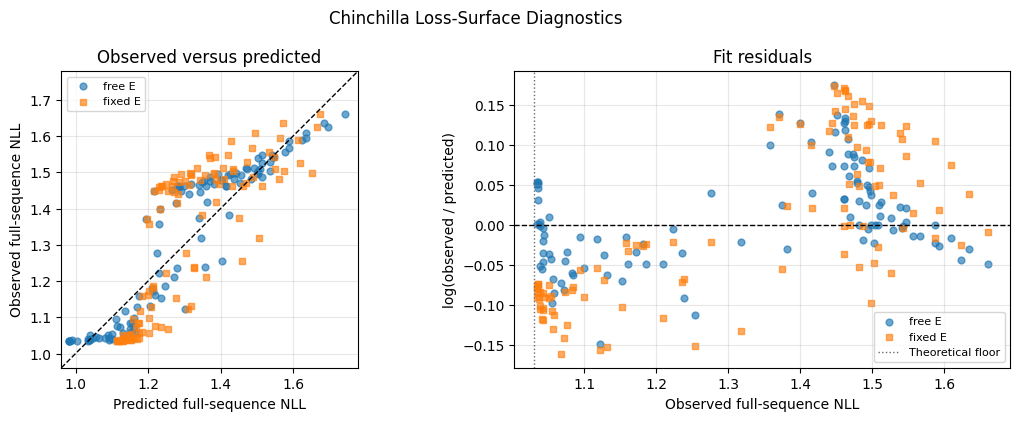

Saved fit diagnostics to: /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/02_dense_addition_scaling_and_transitions/dense-addition-isoflop-v1/analysis/chinchilla_fit_diagnostics.png


In [20]:
# @title
from scaling_transformers_in_jax.scaling_laws import predict_chinchilla_law

FIT_PREDICTIONS = {
    name: predict_chinchilla_law(
        fit,
        FIT_N,
        FIT_D)
    for name, fit in FULL_FITS.items()
}

styles = {
    "free E": ("tab:blue", "o"),
    "fixed E": ("tab:orange", "s"),
}

all_losses = np.concatenate([
    FIT_FULL_NLL,
    *FIT_PREDICTIONS.values(),
])

limit_low = 0.98 * all_losses.min()
limit_high = 1.02 * all_losses.max()

figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.25))

for name, predictions in FIT_PREDICTIONS.items():
  color, marker = styles[name]

  axes[0].scatter(
      predictions,
      FIT_FULL_NLL,
      s=24,
      alpha=0.65,
      color=color,
      marker=marker,
      label=name)

  axes[1].scatter(
      FIT_FULL_NLL,
      np.log(
          FIT_FULL_NLL
          / predictions),
      s=24,
      alpha=0.65,
      color=color,
      marker=marker,
      label=name)

axes[0].plot(
    [limit_low, limit_high],
    [limit_low, limit_high],
    color="black",
    linestyle="--",
    linewidth=1)

axes[0].set(
    xlim=(limit_low, limit_high),
    ylim=(limit_low, limit_high),
    xlabel="Predicted full-sequence NLL",
    ylabel="Observed full-sequence NLL",
    title="Observed versus predicted")

axes[0].set_aspect(
    "equal",
    adjustable="box")

axes[1].axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1)

axes[1].axvline(
    FULL_NLL_FLOOR,
    color="dimgray",
    linestyle=":",
    linewidth=1,
    label="Theoretical floor")

axes[1].set(
    xlabel="Observed full-sequence NLL",
    ylabel="log(observed / predicted)",
    title="Fit residuals")

for axis in axes:
  axis.grid(alpha=0.3)
  axis.legend(fontsize=8)

figure.suptitle(
    "Chinchilla Loss-Surface Diagnostics")

figure.tight_layout()

fit_plot_path = (
    ANALYSIS_DIR
    / "chinchilla_fit_diagnostics.png")

figure.savefig(
    fit_plot_path,
    dpi=150,
    bbox_inches="tight")

plt.show()

print(
    "Saved fit diagnostics to:",
    fit_plot_path)

#### Reading the fit diagnostics

Each marker represents one of the 110 trained endpoints. The left panel
compares the predicted and measured full-sequence NLL; a perfect prediction
would lie on the dashed diagonal. The right panel shows the logarithmic
residual

$$
r
=
\log\left(
\frac{L_{\mathrm{observed}}}
     {L_{\mathrm{predicted}}}
\right).
$$

Positive residuals mean that the fit is too optimistic, while negative
residuals mean that it is too pessimistic. For scale, $|r|=0.1$ corresponds
to a multiplicative discrepancy of approximately $10\%$.

Both fits reproduce the broad variation in loss, but their residuals are
structured rather than randomly distributed around zero. In particular, a
single smooth surface does not capture the relatively sharp change associated
with learning the addition task.

The free-floor fit has the smaller multiplicative error,
$1.064\times$, but drives $E$ to essentially zero and permits predictions
below the known full-sequence floor. The fixed-floor fit respects that limit,
but its error increases to $1.103\times$. Their implied allocations are

$$
\begin{aligned}
\text{free floor:}\quad&
N_{\mathrm{opt}}(C)\propto C^{0.669},
&
D_{\mathrm{opt}}(C)\propto C^{0.331},\\
\text{fixed floor:}\quad&
N_{\mathrm{opt}}(C)\propto C^{0.565},
&
D_{\mathrm{opt}}(C)\propto C^{0.435}.
\end{aligned}
$$

Both estimates are model-heavy, but their numerical difference shows that the
compute-optimal frontier is sensitive to the treatment of the loss floor.

One possible explanation is that the dataset is finite and highly structured.
After one effective epoch, additional processed tokens revisit examples
generated by the same addition rule, rather than continually introducing new
information. This interpretation is plausible but not established by the
present experiment.

We therefore retain both surfaces as local diagnostic summaries. Neither is
reported as a robust Chinchilla-style compute-optimal law.

## Capability-transition scaling

The preceding Chinchilla analyses attempt to describe validation loss as a
smooth function of model size and training exposure. The exact-answer metric
shows a different pattern: performance remains low across part of the grid and
then rises rapidly as the model begins to solve complete addition problems.

Related behavior has been studied by
[Caballero et al. (2023)](https://arxiv.org/abs/2210.14891), who use broken
neural scaling laws to describe arithmetic transitions, and by
[Naidu et al. (2026)](https://ojs.aaai.org/index.php/AAAI/article/view/41111),
who examine abrupt learning transitions across several algorithmic tasks. Here, we
treat the change as an empirical performance boundary. We do not assume that it
corresponds to a discontinuous internal phase transition.

We estimate this boundary in two ways. First, we interpolate one $50\%$
crossing for each model configuration that crosses the threshold within the
measured grid. Second, we fit one shared accuracy surface to all 110 endpoints.

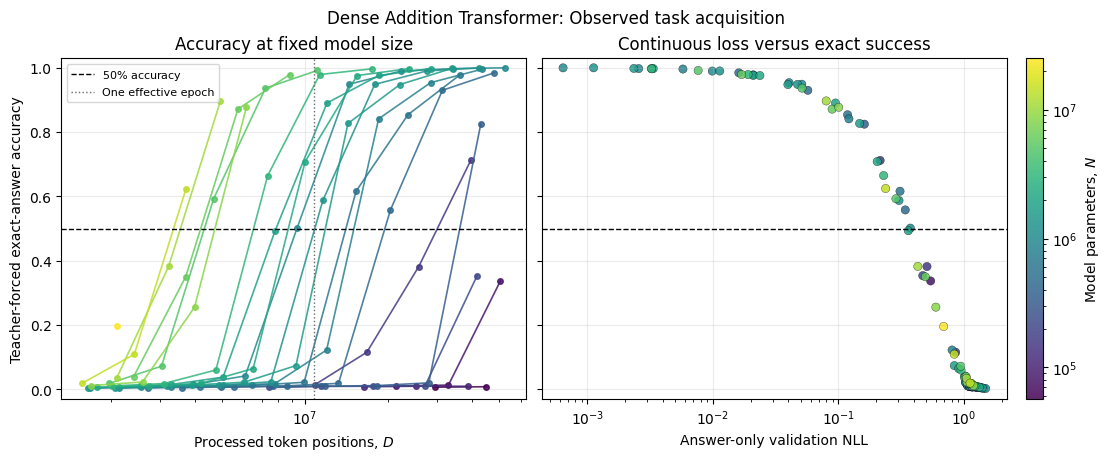

Saved raw transition plot to: /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/02_dense_addition_scaling_and_transitions/dense-addition-isoflop-v1/analysis/capability_transition_raw.png


In [21]:
# @title
from matplotlib.colors import LogNorm


FIT_ANSWER_NLL = np.asarray([
    record["validation"]["answer_loss"]
    for record in RECORDS
], dtype=np.float64)

FIT_ACCURACY = np.asarray([
    record["validation"]["exact_answer_accuracy"]
    for record in RECORDS
], dtype=np.float64)

TRANSITION_MODEL_SIZES = np.unique(
    FIT_N)

parameter_norm = LogNorm(
    vmin=TRANSITION_MODEL_SIZES.min(),
    vmax=TRANSITION_MODEL_SIZES.max())

parameter_cmap = plt.get_cmap(
    "viridis")

one_epoch_d = (
    STEPS_PER_EPOCH
    * BATCH_SIZE
    * SEQ_LEN)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharey=True,
    constrained_layout=True)

for parameter_count in TRANSITION_MODEL_SIZES:
  selected = (
      FIT_N == parameter_count)

  order = np.argsort(
      FIT_D[selected])

  model_d = (
      FIT_D[selected][order])

  model_accuracy = (
      FIT_ACCURACY[selected][order])

  axes[0].plot(
      model_d,
      model_accuracy,
      marker="o",
      markersize=4,
      linewidth=1.2,
      alpha=0.85,
      color=parameter_cmap(
          parameter_norm(
              parameter_count)))

axes[0].axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1,
    label="$50\\%$ accuracy")

axes[0].axvline(
    one_epoch_d,
    color="dimgray",
    linestyle=":",
    linewidth=1,
    label="One effective epoch")

axes[0].set(
    xscale="log",
    xlabel="Processed token positions, $D$",
    ylabel="Teacher-forced exact-answer accuracy",
    title="Accuracy at fixed model size",
    ylim=(-0.03, 1.03))

axes[0].grid(
    alpha=0.25)

axes[0].legend(
    fontsize=8)

answer_points = axes[1].scatter(
    FIT_ANSWER_NLL,
    FIT_ACCURACY,
    c=FIT_N,
    norm=parameter_norm,
    cmap=parameter_cmap,
    s=36,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.25)

axes[1].axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1)

axes[1].set(
    xscale="log",
    xlabel="Answer-only validation NLL",
    title="Continuous loss versus exact success",
    ylim=(-0.03, 1.03))

axes[1].grid(
    alpha=0.25)

colorbar = figure.colorbar(
    answer_points,
    ax=axes,
    pad=0.02)

colorbar.set_label(
    "Model parameters, $N$")

figure.suptitle(
    "Dense Addition Transformer: Observed task acquisition")

raw_transition_plot_path = (
    ANALYSIS_DIR
    / "capability_transition_raw.png")

figure.savefig(
    raw_transition_plot_path,
    dpi=150,
    bbox_inches="tight")

plt.show()

print(
    "Saved raw transition plot to:",
    raw_transition_plot_path)

### Observed transition pattern

In the left panel, each colored line connects independently trained endpoints
with the same model configuration, ordered by processed token positions $D$.
The connecting lines are visual guides, not trajectories from a single
continuing training run. The dashed horizontal line marks $50\%$ exact-answer
accuracy, and the dotted vertical line marks one effective pass through the
training split.

A configuration with measurements below and above $50\%$ has an observed
crossing bracket within the grid. A configuration that remains below $50\%$
is right-censored: under a monotone-threshold interpretation, its crossing
would lie beyond the largest measured budget.

The right panel compares answer-only NLL, a continuous score, with the
all-or-nothing exact-answer metric. NLL can improve gradually while the
fraction of completely correct answers changes sharply. This motivates a
threshold analysis, but the plot alone does not establish a scaling law.

### Estimate 1: one $50\%$ crossing per model configuration

For a target accuracy $r$, define $D_r(N)$ by

$$
q\bigl(N,D_r(N)\bigr)=r.
$$

We focus on $r=0.5$ and denote the corresponding training exposure by
$D_{50}(N)$. For each model configuration, we order the measured endpoints by
$D$ and find the first adjacent pair $(D_1,q_1)$ and $(D_2,q_2)$ satisfying

$$
q_1<0.5\leq q_2.
$$

At the resolution of this experiment, we treat this pair as a bracket for the
threshold. Because the two points come from separately trained,
horizon-matched runs, they do not establish a continuous training trajectory
or prove that accuracy is monotone between them. Interpolation is therefore an
explicit estimation rule rather than an observed crossing time.

The budgets are approximately logarithmically spaced, so we interpolate
linearly in $\log D$:

$$
w=\frac{0.5-q_1}{q_2-q_1},
\qquad
D_{50}=D_1^{1-w}D_2^w.
$$

The interval $[D_1,D_2]$ records the resolution of the training-budget grid.

A configuration whose measured accuracies all remain below $50\%$ is called
right-censored. Under the monotone-threshold interpretation, and assuming a
crossing eventually exists, this gives the one-sided constraint
$D_{50}>D_{\max}$. A configuration whose measured accuracies are all at or
above $50\%$ is left-censored and gives $D_{50}\leq D_{\min}$.

We fit the bracketed point estimates by ordinary least squares in log space:

$$
D_{50}(N)
=
D_0
\left(\frac{N}{1\,\mathrm{M}}\right)^{-p}.
$$

Here, $D_0$ is the fitted boundary at exactly one million parameters, while
$p$ describes how the required training exposure changes with model size.

In [22]:
# @title
def interpolate_accuracy_threshold(threshold):
  """Locate one accuracy threshold for every model family."""

  if not 0.0 < threshold < 1.0:
    raise ValueError(
        "threshold must lie strictly between 0 and 1.")

  rows = []
  left_censored_parameters = []
  right_censored_parameters = []
  unresolved_parameters = []

  for parameter_count in np.unique(
      FIT_N):
    selected = (
        FIT_N == parameter_count)

    token_budgets = FIT_D[selected]
    accuracies = FIT_ACCURACY[selected]

    order = np.argsort(
        token_budgets)

    token_budgets = (
        token_budgets[order])

    accuracies = (
        accuracies[order])

    crossings = np.flatnonzero(
        (accuracies[:-1] < threshold)
        & (accuracies[1:] >= threshold))

    if crossings.size == 0:
      if np.all(
          accuracies < threshold):
        right_censored_parameters.append(
            float(parameter_count))

      elif np.all(
          accuracies >= threshold):
        left_censored_parameters.append(
            float(parameter_count))

      else:
        unresolved_parameters.append(
            float(parameter_count))

      continue

    lower_index = int(
        crossings[0])

    upper_index = (
        lower_index + 1)

    lower_accuracy = float(
        accuracies[lower_index])

    upper_accuracy = float(
        accuracies[upper_index])

    interpolation_fraction = (
        (threshold - lower_accuracy)
        / (
            upper_accuracy
            - lower_accuracy
        )
    )

    log_threshold_d = (
        np.log(
            token_budgets[lower_index])
        + interpolation_fraction
        * (
            np.log(
                token_budgets[upper_index])
            - np.log(
                token_budgets[lower_index])
        )
    )

    rows.append({
        "parameter_count": float(
            parameter_count),
        "lower_d": float(
            token_budgets[lower_index]),
        "upper_d": float(
            token_budgets[upper_index]),
        "lower_accuracy": lower_accuracy,
        "upper_accuracy": upper_accuracy,
        "threshold_d": float(
            np.exp(log_threshold_d)),
    })

  return {
      "threshold": float(threshold),
      "rows": tuple(rows),
      "left_censored": np.asarray(
          left_censored_parameters,
          dtype=np.float64),
      "right_censored": np.asarray(
          right_censored_parameters,
          dtype=np.float64),
      "unresolved": np.asarray(
          unresolved_parameters,
          dtype=np.float64),
  }


def fit_threshold_power_law(
    threshold_result):
  """Fit D_q = D_0 (N / 1M)^(-p) in log space."""

  rows = threshold_result[
      "rows"]

  parameter_counts = np.asarray([
      row["parameter_count"]
      for row in rows
  ], dtype=np.float64)

  threshold_budgets = np.asarray([
      row["threshold_d"]
      for row in rows
  ], dtype=np.float64)

  if parameter_counts.size < 3:
    raise RuntimeError(
        "At least three bracketed model "
        "families are required.")

  log_parameters = np.log(
      parameter_counts / 1e6)

  log_budgets = np.log(
      threshold_budgets)

  slope, intercept = np.polyfit(
      log_parameters,
      log_budgets,
      deg=1)

  predicted_log_budgets = (
      intercept
      + slope * log_parameters)

  residuals = (
      log_budgets
      - predicted_log_budgets)

  residual_sum = np.sum(
      residuals**2)

  total_sum = np.sum(
      (
          log_budgets
          - log_budgets.mean()
      ) ** 2)

  r_squared = float(
      1.0
      - residual_sum / total_sum)

  error_factor = float(
      np.exp(
          np.sqrt(
              np.mean(
                  residuals**2))))

  leave_one_out_exponents = []

  for index in range(
      parameter_counts.size):
    keep = (
        np.arange(
            parameter_counts.size)
        != index)

    held_out_slope, _ = np.polyfit(
        log_parameters[keep],
        log_budgets[keep],
        deg=1)

    leave_one_out_exponents.append(
        -held_out_slope)

  return {
      "parameter_counts": (
          parameter_counts),
      "threshold_budgets": (
          threshold_budgets),
      "D0": float(
          np.exp(intercept)),
      "p": float(-slope),
      "r_squared": r_squared,
      "error_factor": error_factor,
      "residuals": residuals,
      "leave_one_out_p": np.asarray(
          leave_one_out_exponents,
          dtype=np.float64),
  }


D50_RESULT = (
    interpolate_accuracy_threshold(
        threshold=0.5))

if D50_RESULT["unresolved"].size:
  raise RuntimeError(
      "A model family has an unresolved "
      "non-monotone threshold crossing.")

D50_FIT = fit_threshold_power_law(
    D50_RESULT)

D50_ROWS = [
    {
        **row,
        "d50": row["threshold_d"],
    }
    for row in D50_RESULT["rows"]
]

TRANSITION_N = D50_FIT[
    "parameter_counts"]

TRANSITION_D50 = D50_FIT[
    "threshold_budgets"]

TRANSITION_D0 = D50_FIT["D0"]
TRANSITION_P = D50_FIT["p"]
TRANSITION_R2 = D50_FIT[
    "r_squared"]

TRANSITION_ERROR_FACTOR = (
    D50_FIT["error_factor"])

DIRECT_LOO_P = D50_FIT[
    "leave_one_out_p"]

left_censored = (
    D50_RESULT[
        "left_censored"].size)

right_censored = (
    D50_RESULT[
        "right_censored"].size)


print(
    f"{'parameters':>12} | "
    f"{'lower D':>10} | "
    f"{'upper D':>10} | "
    f"{'D50':>10}")

print("-" * 51)

for row in D50_ROWS:
  print(
      f"{row['parameter_count'] / 1e6:>11.3f}M | "
      f"{row['lower_d'] / 1e6:>9.3f}M | "
      f"{row['upper_d'] / 1e6:>9.3f}M | "
      f"{row['d50'] / 1e6:>9.3f}M")

print()

print(
    "Bracketed models:",
    f"{TRANSITION_N.size}/"
    f"{np.unique(FIT_N).size}")

print(
    "Left-censored models:",
    left_censored)

print(
    "Right-censored models:",
    right_censored)

print(
    "Transition law:",
    f"D50 = {TRANSITION_D0 / 1e6:.3f}M "
    f"(N / 1M)^(-{TRANSITION_P:.4f})")

print(
    "Log-space R²:",
    f"{TRANSITION_R2:.4f}")

print(
    "Multiplicative error:",
    f"{TRANSITION_ERROR_FACTOR:.3f}x")

print(
    "Direct leave-one-model-out p range:",
    f"{DIRECT_LOO_P.min():.4f}–"
    f"{DIRECT_LOO_P.max():.4f}")

  parameters |    lower D |    upper D |        D50
---------------------------------------------------
      0.154M |    25.743M |    39.641M |    30.046M
      0.335M |    27.980M |    43.094M |    36.201M
      0.461M |    13.210M |    20.349M |    19.426M
      0.613M |     9.929M |    15.286M |    14.051M
      0.783M |    11.969M |    18.444M |    15.022M
      1.000M |     6.083M |     9.363M |     9.351M
      1.245M |     7.533M |    11.600M |    10.849M
      1.555M |     9.277M |    14.291M |    11.847M
      1.851M |     7.803M |    12.005M |     7.859M
      2.219M |     6.500M |    10.015M |     8.707M
      3.028M |     4.768M |     7.336M |     6.523M
      4.753M |     3.035M |     4.682M |     4.334M
      5.983M |     3.711M |     5.726M |     4.204M
      8.579M |     3.994M |     6.144M |     4.731M
     10.632M |     3.219M |     4.952M |     3.553M
     14.172M |     2.421M |     3.723M |     3.355M

Bracketed models: 16/21
Left-censored models: 0
Right-censored 

#### Per-model result

Sixteen of the twenty-one model configurations bracket a $50\%$ crossing.
Five are right-censored, and none is left-censored. Fitting the sixteen
interpolated crossings gives

$$
D_{50}(N)
=
12.512\,\mathrm{M}
\left(\frac{N}{1\,\mathrm{M}}\right)^{-0.541}.
$$

The normalization $12.512\,\mathrm{M}$ is the regression prediction at exactly
one million parameters. It is not the crossing measured for one particular
model.

For example, the $1{,}000{,}368$-parameter configuration is bracketed by

$$
D_1=6.083\,\mathrm{M},
\qquad
D_2=9.363\,\mathrm{M}.
$$

Its measured accuracies give $w\approx0.997$, so

$$
D_{50}
=
(6.083\,\mathrm{M})^{1-w}
(9.363\,\mathrm{M})^w
=
9.351\,\mathrm{M}.
$$

The difference between $9.351\,\mathrm{M}$ and $12.512\,\mathrm{M}$ is an
ordinary residual from fitting one trend across all sixteen crossings.

On those sixteen point estimates, the fit has log-space $R^2=0.935$, and
exponentiating the log-space RMSE gives a multiplicative residual factor of
$1.198\times$. Leaving out one bracketed configuration at a time gives

$$
0.504\leq p\leq0.560.
$$

This is a sensitivity range, not a confidence interval. The following figure
shows the interpolated crossings and places the fitted trend back onto the full
experiment grid.

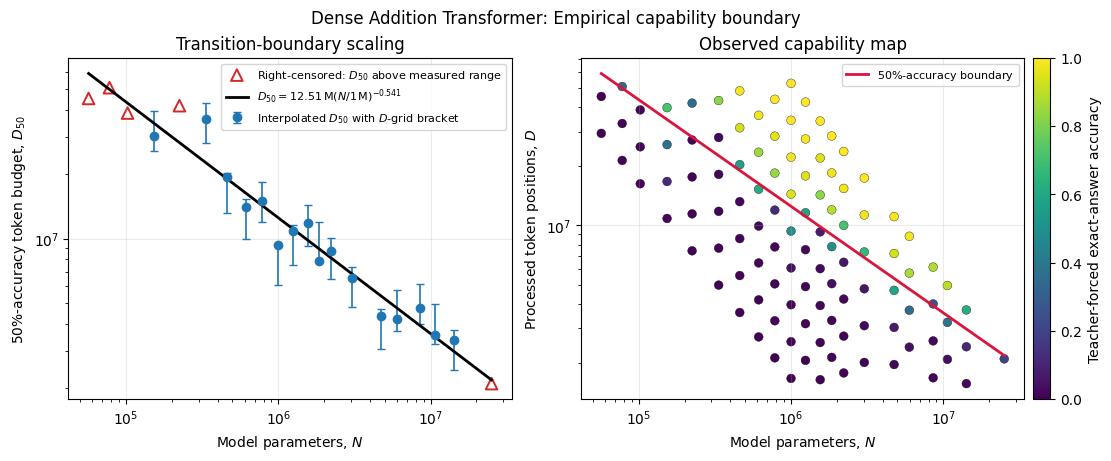

Saved transition plot to: /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/02_dense_addition_scaling_and_transitions/dense-addition-isoflop-v1/analysis/capability_transition_scaling.png


In [23]:
# @title
lower_d = np.asarray([
    row["lower_d"]
    for row in D50_ROWS
], dtype=np.float64)

upper_d = np.asarray([
    row["upper_d"]
    for row in D50_ROWS
], dtype=np.float64)

right_censored_n = D50_RESULT[
    "right_censored"]

left_censored_n = D50_RESULT[
    "left_censored"]

right_censored_d = np.asarray([
    FIT_D[
        FIT_N == parameter_count
    ].max()
    for parameter_count
    in right_censored_n
], dtype=np.float64)

left_censored_d = np.asarray([
    FIT_D[
        FIT_N == parameter_count
    ].min()
    for parameter_count
    in left_censored_n
], dtype=np.float64)

n_curve = np.geomspace(
    FIT_N.min(),
    FIT_N.max(),
    300)

d50_curve = (
    TRANSITION_D0
    * (
        n_curve / 1e6
    ) ** (-TRANSITION_P)
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    constrained_layout=True)

axes[0].errorbar(
    TRANSITION_N,
    TRANSITION_D50,
    yerr=np.vstack((
        TRANSITION_D50 - lower_d,
        upper_d - TRANSITION_D50)),
    fmt="o",
    color="tab:blue",
    ecolor="tab:blue",
    capsize=3,
    linewidth=1.2,
    label=(
        "Interpolated $D_{50}$ "
        "with $D$-grid bracket"))

if right_censored_n.size:
  axes[0].scatter(
      right_censored_n,
      right_censored_d,
      marker="^",
      s=70,
      facecolors="none",
      edgecolors="tab:red",
      linewidths=1.4,
      label=(
          "Right-censored: "
          "$D_{50}$ above measured range"))

if left_censored_n.size:
  axes[0].scatter(
      left_censored_n,
      left_censored_d,
      marker="v",
      s=70,
      facecolors="none",
      edgecolors="tab:orange",
      linewidths=1.4,
      label=(
          "Left-censored: "
          "$D_{50}$ below measured range"))

axes[0].plot(
    n_curve,
    d50_curve,
    color="black",
    linewidth=2,
    label=(
        f"$D_{{50}}="
        f"{TRANSITION_D0 / 1e6:.2f}"
        f"\\,\\mathrm{{M}}"
        f"(N/1\\,\\mathrm{{M}})"
        f"^{{-{TRANSITION_P:.3f}}}$"
    ))

axes[0].set(
    xscale="log",
    yscale="log",
    xlabel="Model parameters, $N$",
    ylabel=(
        "$50\\%$-accuracy token budget, "
        "$D_{50}$"),
    title="Transition-boundary scaling")

axes[0].grid(
    alpha=0.25)

axes[0].legend(
    fontsize=8)

capability_points = axes[1].scatter(
    FIT_N,
    FIT_D,
    c=FIT_ACCURACY,
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    s=40,
    edgecolors="black",
    linewidths=0.25)

axes[1].plot(
    n_curve,
    d50_curve,
    color="crimson",
    linewidth=2,
    label="$50\\%$-accuracy boundary")

axes[1].set(
    xscale="log",
    yscale="log",
    xlabel="Model parameters, $N$",
    ylabel="Processed token positions, $D$",
    title="Observed capability map")

axes[1].grid(
    alpha=0.25)

axes[1].legend(
    fontsize=8)

colorbar = figure.colorbar(
    capability_points,
    ax=axes[1],
    pad=0.02)

colorbar.set_label(
    "Teacher-forced exact-answer accuracy")

figure.suptitle(
    "Dense Addition Transformer: Empirical capability boundary")

transition_plot_path = (
    ANALYSIS_DIR
    / "capability_transition_scaling.png")

figure.savefig(
    transition_plot_path,
    dpi=150,
    bbox_inches="tight")

plt.show()

print(
    "Saved transition plot to:",
    transition_plot_path)

#### Reading the empirical boundary

The left panel shows the interpolated threshold locations and their log-space
power-law fit. The vertical bars extend to the measured endpoints used for
each interpolation. They show the resolution of the training-budget grid, not
statistical uncertainty.

Open upward-pointing triangles represent right-censored model families at
their largest measured training budget. These families remain below $50\%$
accuracy throughout their measured range, so their $D_{50}$ values lie above
the markers and cannot be estimated directly. They are therefore excluded
from the power-law fit.

The right panel shows all 110 trained endpoints in the $N$–$D$ plane, colored
by teacher-forced exact-answer accuracy. The fitted $50\%$ boundary separates
the predominantly unsuccessful and successful regions of the observed grid.

### Estimate 2: one shared accuracy surface

For endpoint $i$, we observe the model size $N_i$, processed-token budget
$D_i$, and exact-answer accuracy $q_i$. We model the predicted mean accuracy as

$$
s_i
=
b_0
+
b_N\log\left(\frac{N_i}{1\,\mathrm{M}}\right)
+
b_D\log\left(\frac{D_i}{1\,\mathrm{M}}\right),
$$

$$
\widehat q_i
=
\sigma(s_i)
=
\frac{1}{1+\exp(-s_i)}.
$$

A negative score predicts an accuracy below $50\%$, a score of zero predicts
$50\%$, and a positive score predicts an accuracy above $50\%$.

We fit the sigmoid directly by minimizing weighted logistic cross-entropy,

$$
L
=
-\sum_i\omega_i
\left[
q_i\log\widehat q_i
+
(1-q_i)\log(1-\widehat q_i)
\right].
$$

Here, $q_i$ is the observed proportion of validation examples answered
correctly. Every model configuration receives the same total weight, even
when configurations contain different numbers of endpoints. We constrain
$b_D>0$, so predicted accuracy is nondecreasing with training exposure, and
use bounded L-BFGS-B from three initializations. Fitting the probability
directly avoids applying a logit transformation to accuracies near zero or one.

The predicted $50\%$ boundary occurs when $s=0$. Solving for $D$ gives

$$
D_{50,\mathrm{global}}(N)
=
D_0
\left(\frac{N}{1\,\mathrm{M}}\right)^{-p},
\qquad
p=\frac{b_N}{b_D},
$$

with

$$
D_0
=
1\,\mathrm{M}
\exp\left(-\frac{b_0}{b_D}\right).
$$

Equivalently, the fitted surface can be written as

$$
\widehat q(N,D)
=
\sigma\left[
b_D
\log\left(
\frac{D}{D_{50,\mathrm{global}}(N)}
\right)
\right].
$$

The word “global” means only that one surface is fitted jointly across this
experimental grid. The model assumes that different configurations share
approximately the same sigmoid shape after their transition locations are
rescaled. The five configurations called right-censored in the first estimate
contribute here through all their measured accuracies; this is not a separate
censored-regression likelihood.

In [24]:
# @title
from scipy.optimize import minimize
from scipy.special import expit


N = np.asarray(
    FIT_N,
    dtype=np.float64)

D = np.asarray(
    FIT_D,
    dtype=np.float64)

accuracy = np.asarray(
    FIT_ACCURACY,
    dtype=np.float64)

model_sizes = np.unique(N)

# Give every model family equal total weight.
weights = np.zeros_like(accuracy)

for parameter_count in model_sizes:
  selected = (
      N == parameter_count)

  weights[selected] = (
      1.0 / selected.sum())

weights /= weights.sum()


# Model: q_hat(N, D) = sigmoid(b0 + bN log(N / 1M) + bD log(D / 1M))
design = np.column_stack((
    np.ones(N.size),
    np.log(N / 1e6),
    np.log(D / 1e6)))


def global_transition_objective(
    coefficients):
  logits = (
      design @ coefficients)

  logistic_losses = (
      np.logaddexp(0.0, logits)
      - accuracy * logits)

  return float(
      np.sum(
          weights
          * logistic_losses))


def global_transition_gradient(
    coefficients):
  logits = (
      design @ coefficients)

  return (
      design.T
      @ (
          weights
          * (
              expit(logits)
              - accuracy)))


mean_accuracy = np.clip(
    np.sum(weights * accuracy),
    1e-6,
    1.0 - 1e-6)

initial_intercept = np.log(
    mean_accuracy
    / (1.0 - mean_accuracy))

starts = (
    np.asarray([
        initial_intercept,
        1.0,
        2.0]),
    np.asarray([
        initial_intercept,
        2.0,
        5.0]),
    np.asarray([
        initial_intercept,
        5.0,
        10.0]),
)

solutions = [
    minimize(
        global_transition_objective,
        start,
        jac=global_transition_gradient,
        method="L-BFGS-B",
        bounds=(
            (-100.0, 100.0),
            (-100.0, 100.0),
            (1e-4, 100.0)),
        options={
            "maxiter": 10_000,
            "ftol": 1e-12,
        })
    for start in starts
]

solutions = [
    solution
    for solution in solutions
    if (
        np.isfinite(solution.fun)
        and np.all(
            np.isfinite(solution.x))
    )
]

if not solutions:
  raise RuntimeError(
      "The global transition fit failed.")

GLOBAL_TRANSITION_FIT = min(
    solutions,
    key=lambda solution: solution.fun)

GLOBAL_B0, GLOBAL_BN, GLOBAL_BD = (
    GLOBAL_TRANSITION_FIT.x)

GLOBAL_TRANSITION_P = float(
    GLOBAL_BN / GLOBAL_BD)

GLOBAL_TRANSITION_D0 = float(
    1e6
    * np.exp(
        -GLOBAL_B0 / GLOBAL_BD))

GLOBAL_ACCURACY_PREDICTION = expit(
    design
    @ GLOBAL_TRANSITION_FIT.x)

GLOBAL_ACCURACY_RMSE = float(
    np.sqrt(
        np.sum(
            weights
            * (
                accuracy
                - GLOBAL_ACCURACY_PREDICTION
            ) ** 2)))


def global_d50(
    parameter_count):
  return (
      GLOBAL_TRANSITION_D0
      * (
          np.asarray(
              parameter_count,
              dtype=np.float64)
          / 1e6
      ) ** (-GLOBAL_TRANSITION_P)
  )


print(
    "Global D50 at 1M parameters:",
    f"{GLOBAL_TRANSITION_D0 / 1e6:.4f}M")

print(
    "Global transition exponent:",
    f"{GLOBAL_TRANSITION_P:.4f}")

print(
    "Common sigmoid slope:",
    f"{GLOBAL_BD:.4f}")

print(
    "Architecture-balanced RMSE:",
    f"{GLOBAL_ACCURACY_RMSE:.4f}")

Global D50 at 1M parameters: 13.9529M
Global transition exponent: 0.5614
Common sigmoid slope: 4.9648
Architecture-balanced RMSE: 0.1338


#### Joint-fit result

The architecture-balanced joint fit gives

$$
D_{50,\mathrm{global}}(N)
=
13.953\,\mathrm{M}
\left(\frac{N}{1\,\mathrm{M}}\right)^{-0.561}.
$$

Its common slope in $\log D$ is $b_D=4.965$, and its
architecture-balanced in-sample accuracy RMSE is $0.134$. The exponent is
close to the per-model crossing estimate. The normalizations need not agree
because this model uses every endpoint and imposes one shared sigmoid shape.

#### Robustness checks

We test sensitivity in three ways: weighting all 110 endpoints equally,
leaving out one complete model configuration at a time, and repeating the
direct crossing analysis at $20\%$, $40\%$, $50\%$, and $70\%$ accuracy.

These checks probe weighting, the influence of individual configurations, and
the choice of threshold. They do not measure variation across training seeds.
Changing the threshold also changes which configurations are bracketed, so the
threshold comparison does not isolate threshold choice alone.

In [25]:
# @title
def fit_transition_subset(
    selected,
    *,
    balance_models):
  """Fit the logistic transition surface to selected endpoints."""

  selected = np.asarray(
      selected,
      dtype=bool)

  subset_design = design[selected]
  subset_accuracy = accuracy[selected]
  subset_parameters = N[selected]

  if balance_models:
    subset_weights = np.zeros_like(
        subset_accuracy)

    for parameter_count in np.unique(
        subset_parameters):
      same_model = (
          subset_parameters
          == parameter_count)

      subset_weights[same_model] = (
          1.0
          / same_model.sum())

  else:
    subset_weights = np.ones_like(
        subset_accuracy)

  subset_weights /= subset_weights.sum()

  def objective(coefficients):
    logits = (
        subset_design
        @ coefficients)

    logistic_losses = (
        np.logaddexp(0.0, logits)
        - subset_accuracy * logits)

    return float(
        np.sum(
            subset_weights
            * logistic_losses))

  def gradient(coefficients):
    logits = (
        subset_design
        @ coefficients)

    return (
        subset_design.T
        @ (
            subset_weights
            * (
                expit(logits)
                - subset_accuracy)))

  solution = minimize(
      objective,
      GLOBAL_TRANSITION_FIT.x,
      jac=gradient,
      method="L-BFGS-B",
      bounds=(
          (-100.0, 100.0),
          (-100.0, 100.0),
          (1e-4, 100.0)),
      options={
          "maxiter": 10_000,
          "ftol": 1e-12,
      })

  if (
      not np.isfinite(solution.fun)
      or np.any(
          ~np.isfinite(solution.x))
  ):
    raise RuntimeError(
        "A transition robustness fit failed.")

  b0, b_n, b_d = solution.x

  predictions = expit(
      subset_design
      @ solution.x)

  return {
      "coefficients": solution.x,
      "D0": float(
          1e6
          * np.exp(-b0 / b_d)),
      "p": float(b_n / b_d),
      "slope": float(b_d),
      "rmse": float(
          np.sqrt(
              np.sum(
                  subset_weights
                  * (
                      subset_accuracy
                      - predictions
                  ) ** 2))),
      "optimizer_success": bool(
          solution.success),
  }


all_endpoints = np.ones(
    N.size,
    dtype=bool)

BALANCED_TRANSITION_FIT = (
    fit_transition_subset(
        all_endpoints,
        balance_models=True)
)

ENDPOINT_WEIGHTED_TRANSITION_FIT = (
    fit_transition_subset(
        all_endpoints,
        balance_models=False)
)


LOO_HELD_OUT_PARAMETERS = (
    model_sizes.copy())

LOO_ACCURACY_PREDICTIONS = np.full(
    accuracy.shape,
    np.nan,
    dtype=np.float64)

loo_transition_p = []
loo_model_rmse = []

for held_out_parameters in (
    LOO_HELD_OUT_PARAMETERS):
  training_subset = (
      N != held_out_parameters)

  held_out_subset = (
      N == held_out_parameters)

  refit = fit_transition_subset(
      training_subset,
      balance_models=True)

  held_out_predictions = expit(
      design[held_out_subset]
      @ refit["coefficients"])

  LOO_ACCURACY_PREDICTIONS[
      held_out_subset
  ] = held_out_predictions

  loo_transition_p.append(
      refit["p"])

  loo_model_rmse.append(
      np.sqrt(
          np.mean(
              (
                  accuracy[held_out_subset]
                  - held_out_predictions
              ) ** 2)))

LOO_TRANSITION_P = np.asarray(
    loo_transition_p,
    dtype=np.float64)

LOO_MODEL_RMSE = np.asarray(
    loo_model_rmse,
    dtype=np.float64)

if np.any(
    ~np.isfinite(
        LOO_ACCURACY_PREDICTIONS)):
  raise RuntimeError(
      "Some held-out endpoints were not predicted.")

# Give every held-out model family equal weight.
LOO_ACCURACY_RMSE = float(
    np.sqrt(
        np.mean(
            LOO_MODEL_RMSE**2)))


THRESHOLD_LEVELS = (
    0.2,
    0.4,
    0.5,
    0.7,
)

THRESHOLD_SENSITIVITY = {}

for threshold in THRESHOLD_LEVELS:
  threshold_result = (
      interpolate_accuracy_threshold(
          threshold))

  if len(
      threshold_result["rows"]
  ) >= 3:
    threshold_fit = (
        fit_threshold_power_law(
            threshold_result))
  else:
    threshold_fit = None

  THRESHOLD_SENSITIVITY[
      threshold
  ] = {
      "result": threshold_result,
      "fit": threshold_fit,
  }


print(
    "Architecture-balanced global fit:",
    f"p={BALANCED_TRANSITION_FIT['p']:.4f}, "
    f"D50(1M)="
    f"{BALANCED_TRANSITION_FIT['D0'] / 1e6:.4f}M, "
    f"RMSE={BALANCED_TRANSITION_FIT['rmse']:.4f}")

print(
    "Endpoint-weighted global fit:",
    f"p={ENDPOINT_WEIGHTED_TRANSITION_FIT['p']:.4f}, "
    f"D50(1M)="
    f"{ENDPOINT_WEIGHTED_TRANSITION_FIT['D0'] / 1e6:.4f}M, "
    f"RMSE={ENDPOINT_WEIGHTED_TRANSITION_FIT['rmse']:.4f}")

print(
    "Leave-one-model-out p range:",
    f"{LOO_TRANSITION_P.min():.4f}–"
    f"{LOO_TRANSITION_P.max():.4f}")

print(
    "Architecture-balanced held-out RMSE:",
    f"{LOO_ACCURACY_RMSE:.4f}")

print()
print("Direct threshold sensitivity")

print(
    f"{'q':>5} | "
    f"{'bracketed':>9} | "
    f"{'left':>4} | "
    f"{'right':>5} | "
    f"{'unresolved':>10} | "
    f"{'Dq(1M)':>9} | "
    f"{'p':>7}")

print("-" * 67)

for threshold in THRESHOLD_LEVELS:
  sensitivity = (
      THRESHOLD_SENSITIVITY[
          threshold])

  threshold_result = (
      sensitivity["result"])

  threshold_fit = (
      sensitivity["fit"])

  bracketed = len(
      threshold_result["rows"])

  left = (
      threshold_result[
          "left_censored"].size)

  right = (
      threshold_result[
          "right_censored"].size)

  unresolved = (
      threshold_result[
          "unresolved"].size)

  if threshold_fit is None:
    d0_text = "--"
    p_text = "--"
  else:
    d0_text = (
        f"{threshold_fit['D0'] / 1e6:.3f}M")

    p_text = (
        f"{threshold_fit['p']:.4f}")

  print(
      f"{threshold:>5.1f} | "
      f"{bracketed:>9} | "
      f"{left:>4} | "
      f"{right:>5} | "
      f"{unresolved:>10} | "
      f"{d0_text:>9} | "
      f"{p_text:>7}")

Architecture-balanced global fit: p=0.5614, D50(1M)=13.9529M, RMSE=0.1338
Endpoint-weighted global fit: p=0.5805, D50(1M)=13.5301M, RMSE=0.1303
Leave-one-model-out p range: 0.5500–0.5869
Architecture-balanced held-out RMSE: 0.1541

Direct threshold sensitivity
    q | bracketed | left | right | unresolved |    Dq(1M) |       p
-------------------------------------------------------------------
  0.2 |        18 |    0 |     3 |          0 |   10.084M |  0.5695
  0.4 |        16 |    0 |     5 |          0 |   11.546M |  0.5389
  0.5 |        16 |    0 |     5 |          0 |   12.512M |  0.5413
  0.7 |        15 |    0 |     6 |          0 |   14.966M |  0.5650


#### Diagnostic setup

Now we examine the shared-sigmoid assumption
$$
\widehat q(N,D)
=
\sigma\left[
b_D
\log\left(
\frac{D}{D_{50,\mathrm{global}}(N)}
\right)
\right].
$$


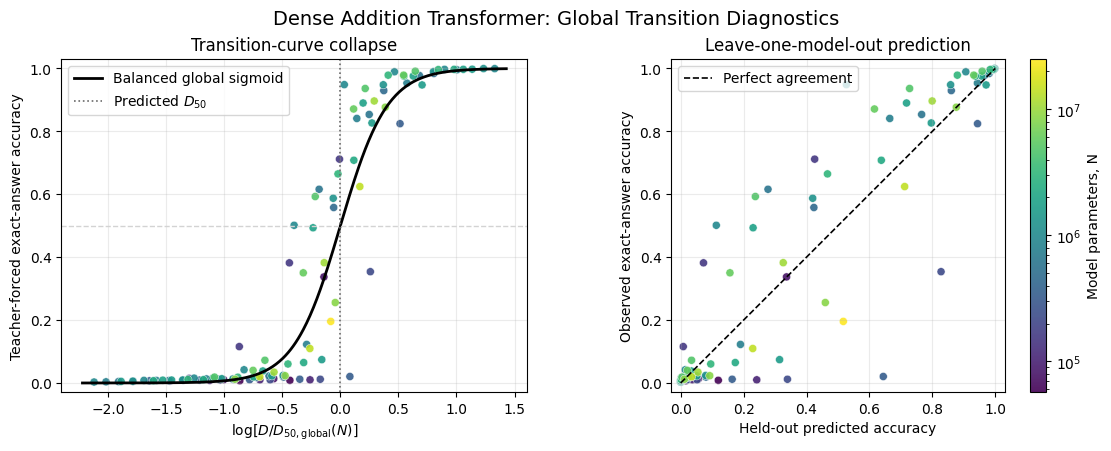

Saved plot to: /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/02_dense_addition_scaling_and_transitions/dense-addition-isoflop-v1/analysis/global_transition_diagnostics.png


In [26]:
# @title
from matplotlib.colors import LogNorm


collapsed_x = np.log(
    D / global_d50(N))

curve_x = np.linspace(
    collapsed_x.min() - 0.1,
    collapsed_x.max() + 0.1,
    500)

curve_accuracy = expit(
    GLOBAL_BD * curve_x)

parameter_norm = LogNorm(
    vmin=N.min(),
    vmax=N.max())

figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.4),
    constrained_layout=True)

collapse_points = axes[0].scatter(
    collapsed_x,
    accuracy,
    c=N,
    cmap="viridis",
    norm=parameter_norm,
    s=34,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.35)

axes[0].plot(
    curve_x,
    curve_accuracy,
    color="black",
    linewidth=2,
    label="Balanced global sigmoid")

axes[0].axvline(
    0.0,
    color="dimgray",
    linestyle=":",
    linewidth=1.2,
    label=r"Predicted $D_{50}$")

axes[0].axhline(
    0.5,
    color="lightgray",
    linestyle="--",
    linewidth=1)

axes[0].set_xlabel(
    r"$\log[D/D_{50,\mathrm{global}}(N)]$")

axes[0].set_ylabel(
    "Teacher-forced exact-answer accuracy")

axes[0].set_title(
    "Transition-curve collapse")

axes[0].set_ylim(
    -0.03,
    1.03)

axes[0].grid(
    alpha=0.25)

axes[0].legend(
    loc="upper left")


axes[1].scatter(
    LOO_ACCURACY_PREDICTIONS,
    accuracy,
    c=N,
    cmap="viridis",
    norm=parameter_norm,
    s=34,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.35)

axes[1].plot(
    [0.0, 1.0],
    [0.0, 1.0],
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Perfect agreement")

axes[1].set_xlabel(
    "Held-out predicted accuracy")

axes[1].set_ylabel(
    "Observed exact-answer accuracy")

axes[1].set_title(
    "Leave-one-model-out prediction")

axes[1].set_xlim(
    -0.03,
    1.03)

axes[1].set_ylim(
    -0.03,
    1.03)

axes[1].set_aspect(
    "equal",
    adjustable="box")

axes[1].grid(
    alpha=0.25)

axes[1].legend(
    loc="upper left")

colorbar = figure.colorbar(
    collapse_points,
    ax=axes,
    pad=0.025)

colorbar.set_label(
    "Model parameters, N")

figure.suptitle(
    "Dense Addition Transformer: Global Transition Diagnostics",
    fontsize=14)

plot_path = (
    ANALYSIS_DIR
    / "global_transition_diagnostics.png")

figure.savefig(
    plot_path,
    dpi=150,
    bbox_inches="tight")

plt.show()

print(
    "Saved plot to:",
    plot_path)

#### Reading the shared-surface diagnostics

The left panel shows that the rescaled measurements follow the broad sigmoid
from near-zero to near-one accuracy. The scatter around its midpoint shows
that the shared surface does not capture the precise transition location or
shape of every model configuration. Because this is an in-sample display, the
apparent collapse is a compatibility check rather than independent validation.

The right panel is stricter: each configuration is predicted without using any
of its own endpoints. Predictions are most accurate in the clearly unlearned
and clearly learned regimes and less precise inside the transition region.

Together, the direct crossing analysis and the joint surface support an
exponent near $0.56$ over this experimental grid. They do not support an exact
accuracy curve obeyed by every configuration. With one fixed seed setting, the
remaining deviations cannot be separated into systematic model effects and
run-to-run variation.

### From training exposure to compute

The fitted capability boundary gives approximately

$$
D_{50}(N)\propto N^{-0.56}.
$$

Doubling model size therefore multiplies the required training exposure by

$$
2^{-0.56}\approx0.68,
$$

corresponding to about $32\%$ fewer processed token positions. This does not
mean that the larger model uses less compute. Since

$$
C\approx6ND,
$$

the approximate compute at the boundary scales as

$$
C_{50}(N)
=
6ND_{50}(N)
\propto
N^{1-0.56}
=
N^{0.44}.
$$

Doubling model size therefore multiplies transition compute by

$$
2^{0.44}\approx1.36.
$$

Larger models cross the fitted boundary after processing fewer token
positions, but still require more approximate compute.

This is not a Chinchilla compute-optimal frontier. A Chinchilla frontier
minimizes loss subject to a fixed compute budget. The present curve instead
describes combinations of $N$ and $D$ associated with a fixed level of task
performance.

## Conclusion

The 110-run sweep does not identify a robust Chinchilla-style compute-optimal
frontier. The IsoFLOP profiles do not consistently form smooth valleys, and
the allocation inferred from the direct loss-surface fit changes substantially
when the irreducible loss floor is fixed rather than estimated.

A clearer relationship appears in exact task acquisition. The primary joint
fit is

$$
D_{50,\mathrm{global}}(N)
\approx
14\,\mathrm{M}
\left(\frac{N}{1\,\mathrm{M}}\right)^{-0.56}.
$$

The per-model crossing estimate gives $p=0.541$. Across threshold choices,
weighting choices, and leave-one-model-out refits, the observed exponents range
from $0.504$ to $0.587$. The stable conclusion is therefore approximate:
within this model ladder, larger models require fewer processed token positions
to reach the capability boundary, while their approximate transition compute
still increases.

These results are specific to the present architecture ladder, finite addition
dataset, horizon-matched optimization protocol, teacher-forced metric, and
single fixed seed setting. They describe the clearest empirical relationship
supported by this experiment, not a universal law for arithmetic or language
modelling.